In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing / IO
from scipy.io import loadmat

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set()

In [2]:
FILEPATH_MAT = "S1_E1_A1.mat"
FS = 2000

# Inputs: EMG channels corresponding to thumb/index/middle/ring/pinky (0-based)
EMG_CHANNELS_0BASED = [3, 6, 8, 11, 14]
FINGER_NAMES = ["thumb", "index", "middle", "ring", "pinky"]

# Targets: glove joint angles 3, 6, 8, 11, 14 (1-based in the hand picture)
GLOVE_JOINTS_1BASED = [3, 6, 8, 11, 14]

# Window parameter grid
WINDOW_SIZES = [100, 150, 200, 250, 300]  # samples (50-150ms at 2000Hz)
STEP_SIZES = [25, 50, 75, 100]  # samples (12.5-50ms)

TRAIN_PCT = 0.6
VAL_PCT = 0.2
TEST_PCT = 0.2
CV_K = round((TRAIN_PCT + VAL_PCT) / VAL_PCT)  # 4 for 60/20/20
assert abs(TRAIN_PCT + VAL_PCT + TEST_PCT - 1.0) < 1e-12

In [3]:
data = loadmat(FILEPATH_MAT)
print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
glove = data["glove"]
stimulus = data["restimulus"]
repetition = data["rerepetition"]

# time alignment
assert emg.shape[0] == glove.shape[0] == stimulus.shape[0] == repetition.shape[0]

stimulus_1d = stimulus.squeeze().astype(int)
repetition_1d = repetition.squeeze().astype(int)

N_STIMULI = len(np.unique(stimulus_1d)) - 1  # -1 because 0 is resting condition
N_REPETITIONS = len(np.unique(repetition_1d)) - 1  # -1 because 0 is not a repetition

# Ensure glove is 2D: (n_samples, n_glove_dims)
glove_2d = glove
if glove_2d.ndim == 1:
    glove_2d = glove_2d.reshape(-1, 1)
elif glove_2d.ndim > 2:
    glove_2d = glove_2d.reshape(glove_2d.shape[0], -1)

# Selecting glove targets
joint_idx = [j - 1 for j in GLOVE_JOINTS_1BASED]
assert max(joint_idx) < glove_2d.shape[1], "Selected glove indices exceed available glove dimensions."
glove_sel = glove_2d[:, joint_idx]
joint_names = [f"angle{j}" for j in GLOVE_JOINTS_1BASED]

# Selecting EMG channels
assert len(EMG_CHANNELS_0BASED) == len(FINGER_NAMES)
assert max(EMG_CHANNELS_0BASED) < emg.shape[1], "Selected EMG channel index exceeds available channels."
emg_sel = emg[:, EMG_CHANNELS_0BASED]
channel_labels = FINGER_NAMES

n_samples, n_channels = emg_sel.shape
print(f"EMG selected shape: {emg_sel.shape}")
print(f"Glove selected shape: {glove_sel.shape}")
print(f"Stimuli: {N_STIMULI} | Repetitions: {N_REPETITIONS}")


Dataset variables:
['subject', 'exercise', 'emg', 'acc', 'gyro', 'mag', 'glove', 'stimulus', 'repetition', 'restimulus', 'rerepetition']
EMG selected shape: (2292526, 5)
Glove selected shape: (2292526, 5)
Stimuli: 9 | Repetitions: 10



VISUALIZING RAW DATA


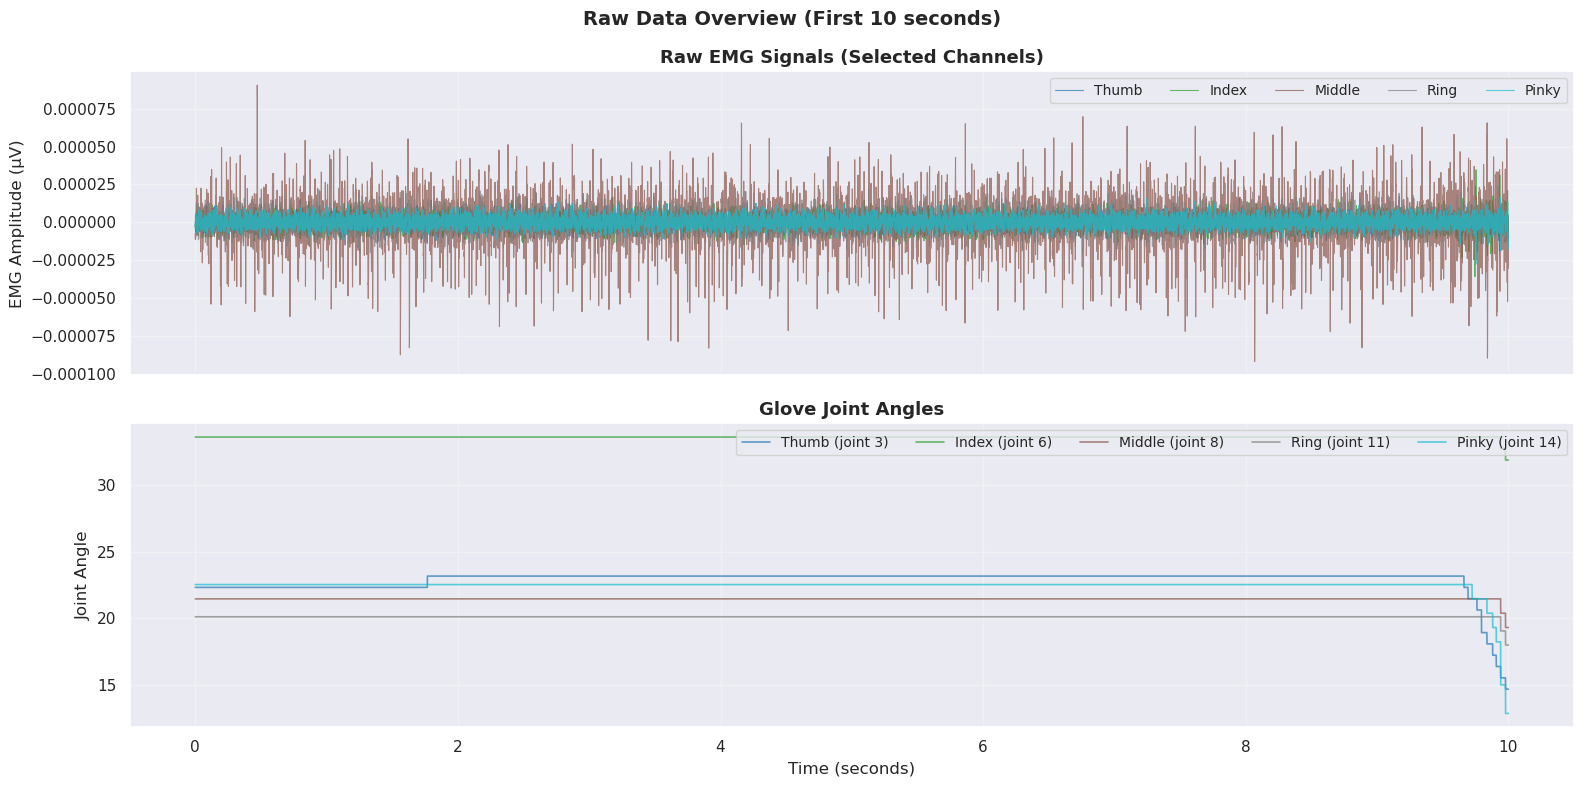

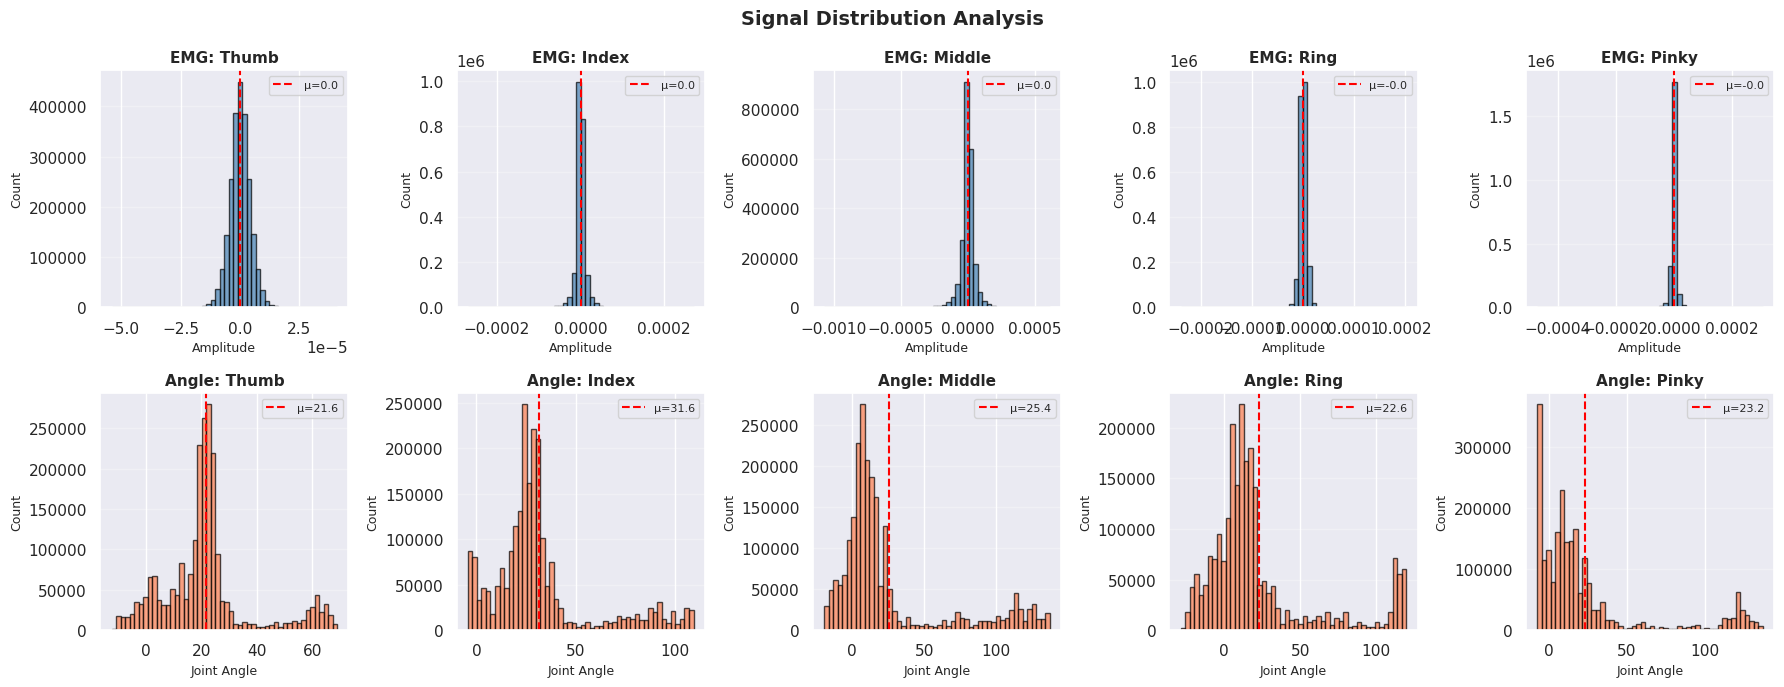

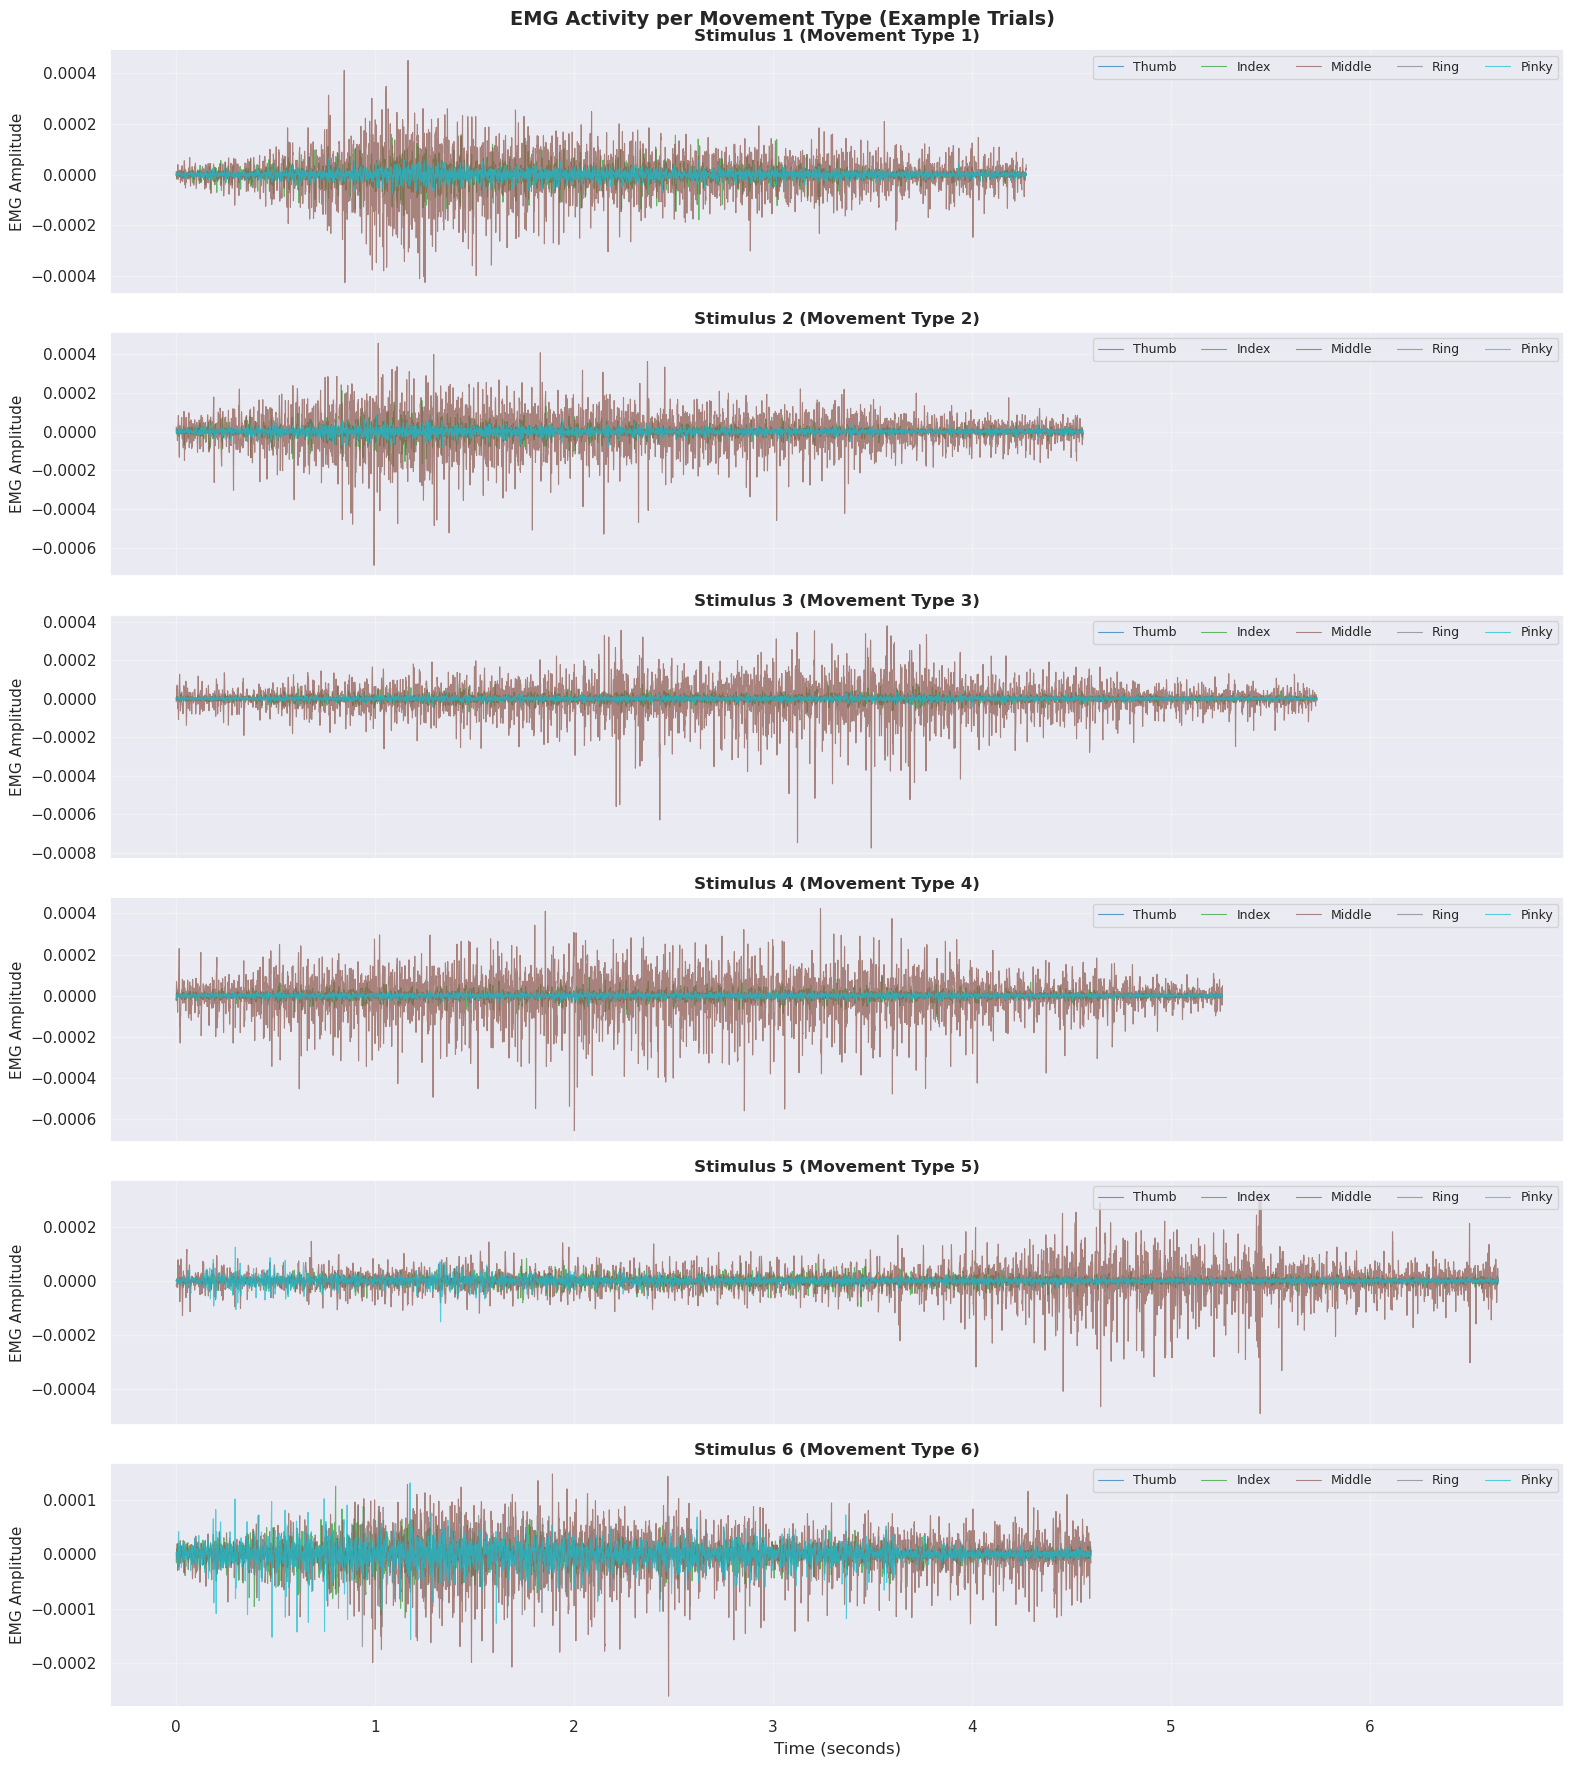


DATA SUMMARY STATISTICS

Finger EMG Mean EMG Std   EMG Range Angle Mean Angle Std    Angle Range
 Thumb     0.00    0.00 [-0.0, 0.0]      21.59     16.31  [-12.4, 68.9]
 Index     0.00    0.00 [-0.0, 0.0]      31.62     25.63  [-4.3, 109.4]
Middle     0.00    0.00 [-0.0, 0.0]      25.43     39.12 [-19.3, 137.3]
  Ring    -0.00    0.00 [-0.0, 0.0]      22.64     36.03 [-28.6, 119.6]
 Pinky    -0.00    0.00 [-0.0, 0.0]      23.23     37.24  [-7.5, 137.3]


Total samples: 2,292,526
Sampling rate: 2000 Hz
Duration: 1146.3 seconds
Number of stimuli: 9
Number of repetitions: 10
Total trials: 90


In [4]:
# ============================================================================
# INITIAL DATA VISUALIZATION
# ============================================================================
print("\n" + "="*70)
print("VISUALIZING RAW DATA")
print("="*70)

# 1. OVERVIEW: Raw EMG and Glove signals (first 10 seconds)
# ============================================================================
n_samples_plot = int(10 * FS)  # 10 seconds
time_axis = np.arange(n_samples_plot) / FS  # Convert to seconds

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# EMG signals
for i, (ch_name, color) in enumerate(zip(FINGER_NAMES, plt.cm.tab10(np.linspace(0, 1, 5)))):
    ax1.plot(time_axis, emg_sel[:n_samples_plot, i], 
             label=ch_name.capitalize(), color=color, alpha=0.7, linewidth=0.8)

ax1.set_ylabel('EMG Amplitude (μV)', fontsize=12)
ax1.set_title('Raw EMG Signals (Selected Channels)', fontsize=13, fontweight='bold')
ax1.legend(ncol=5, loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Glove signals (joint angles)
for i, (joint_name, color) in enumerate(zip(joint_names, plt.cm.tab10(np.linspace(0, 1, 5)))):
    ax2.plot(time_axis, glove_sel[:n_samples_plot, i], 
             label=f'{FINGER_NAMES[i].capitalize()} (joint {GLOVE_JOINTS_1BASED[i]})', 
             color=color, alpha=0.7, linewidth=1.2)

ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Joint Angle', fontsize=12)
ax2.set_title('Glove Joint Angles', fontsize=13, fontweight='bold')
ax2.legend(ncol=5, loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Raw Data Overview (First 10 seconds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 2. DATA DISTRIBUTION: Histograms of signals
# ============================================================================
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# EMG distributions
for i, (ax, finger) in enumerate(zip(axes[0], FINGER_NAMES)):
    ax.hist(emg_sel[:, i], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'EMG: {finger.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Amplitude', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    mean_val = np.mean(emg_sel[:, i])
    std_val = np.std(emg_sel[:, i])
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
               label=f'μ={mean_val:.1f}')
    ax.legend(fontsize=8)

# Glove angle distributions
for i, (ax, finger) in enumerate(zip(axes[1], FINGER_NAMES)):
    ax.hist(glove_sel[:, i], bins=50, color='coral', alpha=0.7, edgecolor='black')
    ax.set_title(f'Angle: {finger.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Joint Angle', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    mean_val = np.mean(glove_sel[:, i])
    std_val = np.std(glove_sel[:, i])
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
               label=f'μ={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Signal Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 3. STIMULUS-BASED VISUALIZATION: EMG activity per movement type
# ============================================================================
# Show one example trial for each stimulus
unique_stimuli = np.unique(stimulus_1d[stimulus_1d > 0])
n_stimuli_plot = min(6, len(unique_stimuli))  # Show max 6 stimuli

fig, axes = plt.subplots(n_stimuli_plot, 1, figsize=(16, 3*n_stimuli_plot), sharex=True)
if n_stimuli_plot == 1:
    axes = [axes]

for idx, stim in enumerate(unique_stimuli[:n_stimuli_plot]):
    # Get one trial for this stimulus (first repetition)
    mask = (stimulus_1d == stim) & (repetition_1d == 1)
    if not np.any(mask):
        continue
    
    trial_indices = np.flatnonzero(mask)
    trial_emg = emg_sel[mask, :]
    trial_glove = glove_sel[mask, :]
    trial_time = np.arange(len(trial_indices)) / FS
    
    # Plot EMG for all channels
    for i, (finger, color) in enumerate(zip(FINGER_NAMES, plt.cm.tab10(np.linspace(0, 1, 5)))):
        axes[idx].plot(trial_time, trial_emg[:, i], 
                      label=finger.capitalize(), color=color, alpha=0.7, linewidth=0.8)
    
    axes[idx].set_ylabel('EMG Amplitude', fontsize=11)
    axes[idx].set_title(f'Stimulus {stim} (Movement Type {stim})', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(ncol=5, loc='upper right', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)', fontsize=12)
plt.suptitle('EMG Activity per Movement Type (Example Trials)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. SUMMARY STATISTICS TABLE
# ============================================================================
print("\n" + "="*70)
print("DATA SUMMARY STATISTICS")
print("="*70)

summary_data = []
for i, finger in enumerate(FINGER_NAMES):
    summary_data.append({
        'Finger': finger.capitalize(),
        'EMG Mean': f"{np.mean(emg_sel[:, i]):.2f}",
        'EMG Std': f"{np.std(emg_sel[:, i]):.2f}",
        'EMG Range': f"[{np.min(emg_sel[:, i]):.1f}, {np.max(emg_sel[:, i]):.1f}]",
        'Angle Mean': f"{np.mean(glove_sel[:, i]):.2f}",
        'Angle Std': f"{np.std(glove_sel[:, i]):.2f}",
        'Angle Range': f"[{np.min(glove_sel[:, i]):.1f}, {np.max(glove_sel[:, i]):.1f}]",
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))
print("\n" + "="*70)

print(f"\nTotal samples: {emg_sel.shape[0]:,}")
print(f"Sampling rate: {FS} Hz")
print(f"Duration: {emg_sel.shape[0]/FS:.1f} seconds")
print(f"Number of stimuli: {N_STIMULI}")
print(f"Number of repetitions: {N_REPETITIONS}")
print(f"Total trials: {N_STIMULI * N_REPETITIONS}")

In [5]:
def extract_sliding_windows(emg_sel, glove_sel, stimulus_1d, repetition_1d, 
                            window_size, step_size, n_channels):
    """
    Extract sliding windows from EMG/glove data.
    
    Returns:
        X, Y, labels, meta arrays
    """
    # Only use data where there's actual movement (stimulus > 0)
    active_mask = stimulus_1d > 0
    emg_active = emg_sel[active_mask, :]
    glove_active = glove_sel[active_mask, :]
    stimulus_active = stimulus_1d[active_mask]
    repetition_active = repetition_1d[active_mask]
    
    X_list: list[np.ndarray] = []
    Y_list: list[np.ndarray] = []
    labels_list: list[int] = []
    meta_list: list[tuple[int, int, int, int, int]] = []
    
    n_samples_active = emg_active.shape[0]
    window_idx = 0
    
    for start in range(0, n_samples_active - window_size + 1, step_size):
        end = start + window_size
        
        window_emg = emg_active[start:end, :]
        window_glove = glove_active[start:end, :]
        window_stimulus = stimulus_active[start:end]
        window_repetition = repetition_active[start:end]
        
        # Only keep windows from single stimulus/repetition
        if len(np.unique(window_stimulus)) > 1 or len(np.unique(window_repetition)) > 1:
            continue
        
        features = extract_features_one_trial(window_emg)
        target = np.mean(window_glove, axis=0)
        label = int(window_stimulus[0])
        
        X_list.append(features)
        Y_list.append(target)
        labels_list.append(label)
        meta_list.append((window_idx, label, int(window_repetition[0]), start, window_size))
        
        window_idx += 1
    
    X = np.vstack(X_list) if X_list else np.empty((0, n_channels * len(FEATURE_FUNCS)))
    Y = np.vstack(Y_list) if Y_list else np.empty((0, glove_sel.shape[1]))
    labels = np.asarray(labels_list, dtype=int)
    meta = np.asarray(meta_list, dtype=int)

    print(f"Trials kept: {X.shape[0]} | Features/trial: {X.shape[1]} | Targets/trial: {Y.shape[1]}")
    if meta.size:
        lengths = meta[:, 4]
        print(f"Trial length (samples): min={lengths.min()} | median={int(np.median(lengths))} | max={lengths.max()}")
    
    # Feature names: n_features per selected channel
    feature_names: list[str] = []
    for ch in range(n_channels):
        for feat_name in FEATURE_FUNCS:
            feature_names.append(f"{feat_name}_{channel_labels[ch]}")
    
    df_features = pd.DataFrame(X, columns=feature_names)

    # Remove non-finite values
    finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    X = X[finite_mask]
    Y = Y[finite_mask]
    labels = labels[finite_mask]
    meta = meta[finite_mask]
    
    return X, Y, labels, meta, feature_names

In [6]:
eps = 1e-12

def _tkeo_mean(x: np.ndarray) -> float:
    # Teager–Kaiser energy operator: ψ[x[n]] = x[n]^2 - x[n-1]x[n+1]
    if x.size < 3:
        return 0.0
    return float(np.mean(x[1:-1] ** 2 - x[:-2] * x[2:]))

def _hoyer_sparsity(x: np.ndarray, eps: float = 1e-12) -> float:
    # Hoyer sparsity in [0, 1]. Use abs(.) for EMG.
    v = np.abs(x).astype(float)
    n = v.size
    if n == 0:
        return 0.0
    l1 = np.sum(v)
    l2 = np.linalg.norm(v)
    if l2 < eps:
        return 0.0
    return float((np.sqrt(n) - (l1 / (l2 + eps))) / (np.sqrt(n) - 1.0 + eps))

def _irregularity_factor(x: np.ndarray, eps: float = 1e-12) -> float:
    # Time-domain irregularity: energy of first difference relative to signal energy
    if x.size < 2:
        return 0.0
    num = np.mean(np.diff(x) ** 2)
    den = np.mean(x ** 2)
    return float(np.sqrt((num + eps) / (den + eps)))

def _waveform_length_ratio(x: np.ndarray, eps: float = 1e-12) -> float:
    # Normalized waveform length: WL / sum(|x|)
    if x.size < 2:
        return 0.0
    wl = np.sum(np.abs(np.diff(x)))
    amp = np.sum(np.abs(x))
    return float(wl / (amp + eps))

FEATURE_FUNCS = {
    "mean": lambda x: float(np.mean(x)),
    "std": lambda x: float(np.std(x, ddof=0)),
    "max_amp": lambda x: float(np.max(np.abs(x))),
    "tkeo": _tkeo_mean,
    "sparsity": _hoyer_sparsity,
    "irregularity": _irregularity_factor,
    "wl_ratio": _waveform_length_ratio,
}

def extract_features_one_trial(trial_emg: np.ndarray) -> np.ndarray:
    """
    trial_emg: shape (n_samples_in_trial, n_channels)
    returns: shape (n_channels * n_features,)
    """
    feats: list[float] = []
    for ch in range(trial_emg.shape[1]):
        x = trial_emg[:, ch].astype(float)
        for name in FEATURE_FUNCS:
            feats.append(FEATURE_FUNCS[name](x))
    return np.asarray(feats, dtype=float)

def build_model(params: dict) -> Pipeline:
    gbr = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        criterion=params["criterion"],
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", MultiOutputRegressor(gbr, n_jobs=-1)),
    ])


In [7]:
# ============================================================================
# WINDOW PARAMETER GRID SEARCH
# ============================================================================
print("\n" + "="*70)
print("GRID SEARCH OVER WINDOW PARAMETERS")
print("="*70)

# Storage for results
window_results = []

for window_size in WINDOW_SIZES:
    for step_size in STEP_SIZES:
        # Skip invalid combinations (step > window)
        if step_size > window_size:
            continue
        
        overlap_pct = (1 - step_size/window_size) * 100
        print(f"\n{'='*70}")
        print(f"Testing: window={window_size} ({window_size/FS*1000:.1f}ms), "
              f"step={step_size} ({step_size/FS*1000:.1f}ms), overlap={overlap_pct:.1f}%")
        print(f"{'='*70}")
        
        # Extract windows with current parameters
        X, Y, labels, meta, feature_names = extract_sliding_windows(
            emg_sel, glove_sel, stimulus_1d, repetition_1d,
            window_size, step_size, n_channels
        )
        
        print(f"Extracted {X.shape[0]} windows")
        
        # Skip if too few samples
        if X.shape[0] < 100:
            print("⚠️  Too few windows, skipping...")
            continue
        
        # Train/val/test split
        try:
            X_trainval, X_test, Y_trainval, Y_test, labels_trainval, labels_test = train_test_split(
                X, Y, labels,
                test_size=TEST_PCT,
                random_state=RANDOM_STATE,
                stratify=labels,
            )
            
            X_train, X_val, Y_train, Y_val, labels_train, labels_val = train_test_split(
                X_trainval, Y_trainval, labels_trainval,
                test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
                random_state=RANDOM_STATE,
                stratify=labels_trainval,
            )
        except ValueError as e:
            print(f"⚠️  Split failed: {e}")
            continue
        
        print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
        
        # Quick model training (use a fast baseline, not full grid search)
        # Option 1: Use a single "reasonable" hyperparameter set
        baseline_params = {
            "n_estimators": 100,
            "learning_rate": 0.05,
            "max_depth": 3,
            "subsample": 0.8,
            "criterion": "friedman_mse",
        }
        
        model = build_model(baseline_params)
        
        try:
            model.fit(X_train, Y_train)
            
            # Evaluate
            Y_val_pred = model.predict(X_val)
            Y_test_pred = model.predict(X_test)
            
            val_r2 = float(r2_score(Y_val, Y_val_pred, multioutput="variance_weighted"))
            val_rmse = float(np.sqrt(mean_squared_error(Y_val, Y_val_pred)))
            test_r2 = float(r2_score(Y_test, Y_test_pred, multioutput="variance_weighted"))
            test_rmse = float(np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
            
            # Per-finger R² on validation set
            r2_per_finger = [r2_score(Y_val[:, i], Y_val_pred[:, i]) 
                            for i in range(Y_val.shape[1])]
            
            print(f"\n📊 Results:")
            print(f"  Val R²: {val_r2:+.4f} | Val RMSE: {val_rmse:.4f}")
            print(f"  Test R²: {test_r2:+.4f} | Test RMSE: {test_rmse:.4f}")
            print(f"  Per-finger Val R²: {[f'{r:.3f}' for r in r2_per_finger]}")
            
            # Store results
            window_results.append({
                'window_size': window_size,
                'step_size': step_size,
                'window_ms': window_size/FS*1000,
                'step_ms': step_size/FS*1000,
                'overlap_pct': overlap_pct,
                'n_windows': X.shape[0],
                'val_r2': val_r2,
                'val_rmse': val_rmse,
                'test_r2': test_r2,
                'test_rmse': test_rmse,
                'r2_per_finger': r2_per_finger,
                'X_train': X_train,
                'X_val': X_val,
                'X_test': X_test,
                'Y_train': Y_train,
                'Y_val': Y_val,
                'Y_test': Y_test,
            })
            
        except Exception as e:
            print(f"⚠️  Training failed: {e}")
            continue

print(f"\n{'='*70}")
print(f"Completed {len(window_results)} window parameter combinations")
print(f"{'='*70}\n")


GRID SEARCH OVER WINDOW PARAMETERS

Testing: window=100 (50.0ms), step=25 (12.5ms), overlap=75.0%
Trials kept: 43816 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=100 | median=100 | max=100
Extracted 43816 windows
Train: 26289 | Val: 8763 | Test: 8764

📊 Results:
  Val R²: +0.5533 | Val RMSE: 28.6008
  Test R²: +0.5547 | Test RMSE: 28.5577
  Per-finger Val R²: ['0.379', '0.418', '0.430', '0.641', '0.711']

Testing: window=100 (50.0ms), step=50 (25.0ms), overlap=50.0%
Trials kept: 21908 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=100 | median=100 | max=100
Extracted 21908 windows
Train: 13144 | Val: 4382 | Test: 4382

📊 Results:
  Val R²: +0.5650 | Val RMSE: 28.3800
  Test R²: +0.5544 | Test RMSE: 28.6229
  Per-finger Val R²: ['0.387', '0.446', '0.439', '0.650', '0.723']

Testing: window=100 (50.0ms), step=75 (37.5ms), overlap=25.0%
Trials kept: 14601 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=100 | median=100 | max


TOP 5 WINDOW CONFIGURATIONS (by Validation R²)
 window_size  step_size  window_ms  step_ms  overlap_pct  n_windows   val_r2  val_rmse  test_r2  test_rmse
         300         75      150.0     37.5    75.000000      14365 0.697172 23.789465 0.693473  23.767497
         300         25      150.0     12.5    91.666667      43096 0.692985 23.887130 0.692877  23.741458
         300         50      150.0     25.0    83.333333      21548 0.690074 23.982229 0.687342  23.996222
         300        100      150.0     50.0    66.666667      10774 0.686833 24.362363 0.690037  23.943454
         250         25      125.0     12.5    90.000000      43276 0.681003 24.356710 0.669976  24.620290


🏆 BEST WINDOW CONFIGURATION
Window size: 300 samples (150.0 ms)
Step size: 75 samples (37.5 ms)
Overlap: 75.0%
Number of windows: 14365
Validation R²: +0.6972
Test R²: +0.6935
Per-finger Val R²: ['0.549', '0.602', '0.604', '0.758', '0.823']



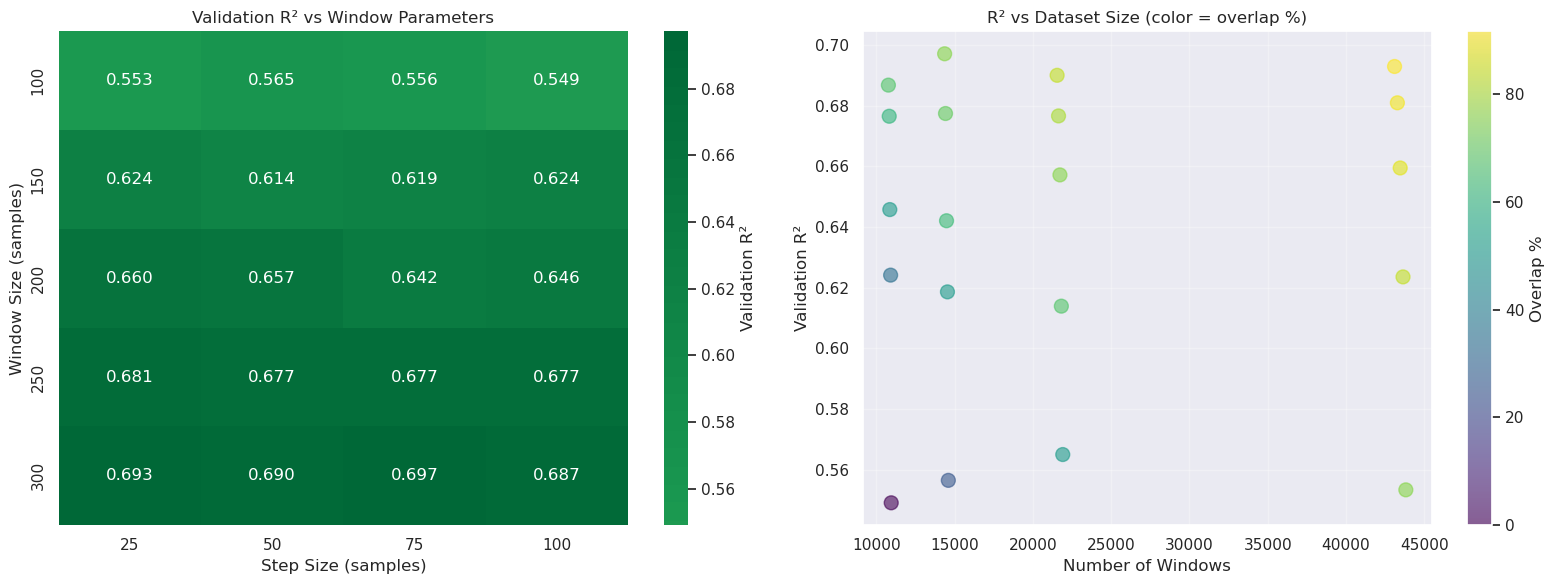

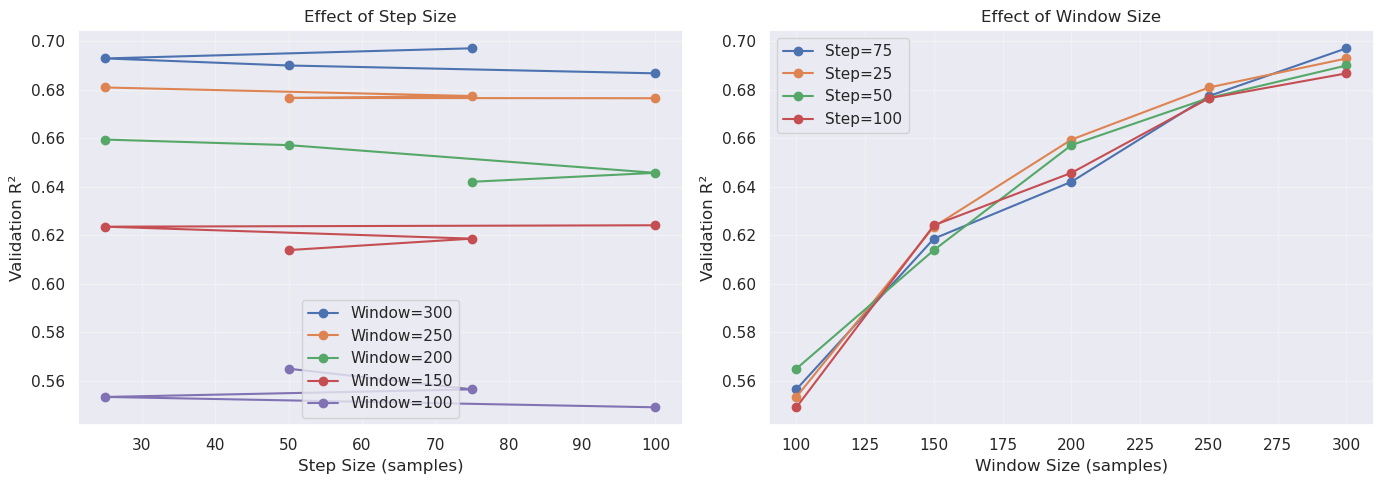

In [8]:
# ============================================================================
# WINDOW PARAMETER RESULTS ANALYSIS
# ============================================================================

if not window_results:
    print("❌ No valid window configurations found!")
else:
    # Convert to DataFrame for easier analysis
    df_window_results = pd.DataFrame([
        {
            'window_size': r['window_size'],
            'step_size': r['step_size'],
            'window_ms': r['window_ms'],
            'step_ms': r['step_ms'],
            'overlap_pct': r['overlap_pct'],
            'n_windows': r['n_windows'],
            'val_r2': r['val_r2'],
            'val_rmse': r['val_rmse'],
            'test_r2': r['test_r2'],
            'test_rmse': r['test_rmse'],
        }
        for r in window_results
    ])
    
    # Sort by validation R²
    df_window_results = df_window_results.sort_values('val_r2', ascending=False)
    
    print("\n" + "="*70)
    print("TOP 5 WINDOW CONFIGURATIONS (by Validation R²)")
    print("="*70)
    print(df_window_results.head(5).to_string(index=False))
    print()
    
    # Best configuration
    best_idx = df_window_results['val_r2'].idxmax()
    best_config = window_results[best_idx]
    
    print("\n" + "="*70)
    print("🏆 BEST WINDOW CONFIGURATION")
    print("="*70)
    print(f"Window size: {best_config['window_size']} samples ({best_config['window_ms']:.1f} ms)")
    print(f"Step size: {best_config['step_size']} samples ({best_config['step_ms']:.1f} ms)")
    print(f"Overlap: {best_config['overlap_pct']:.1f}%")
    print(f"Number of windows: {best_config['n_windows']}")
    print(f"Validation R²: {best_config['val_r2']:+.4f}")
    print(f"Test R²: {best_config['test_r2']:+.4f}")
    print(f"Per-finger Val R²: {[f'{r:.3f}' for r in best_config['r2_per_finger']]}")
    print("="*70 + "\n")
    
    # Visualization 1: Heatmap of R² scores
    pivot_r2 = df_window_results.pivot(
        index='window_size', 
        columns='step_size', 
        values='val_r2'
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn', 
                center=0, ax=axes[0], cbar_kws={'label': 'Validation R²'})
    axes[0].set_title('Validation R² vs Window Parameters')
    axes[0].set_xlabel('Step Size (samples)')
    axes[0].set_ylabel('Window Size (samples)')
    
    # Visualization 2: R² vs number of windows (to check if more data helps)
    axes[1].scatter(df_window_results['n_windows'], 
                   df_window_results['val_r2'], 
                   c=df_window_results['overlap_pct'],
                   cmap='viridis', s=100, alpha=0.6)
    axes[1].set_xlabel('Number of Windows')
    axes[1].set_ylabel('Validation R²')
    axes[1].set_title('R² vs Dataset Size (color = overlap %)')
    axes[1].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
    cbar.set_label('Overlap %')
    
    plt.tight_layout()
    plt.show()
    
    # Visualization 3: Effect of window size and step size separately
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Group by window size
    for ws in df_window_results['window_size'].unique():
        subset = df_window_results[df_window_results['window_size'] == ws]
        axes[0].plot(subset['step_size'], subset['val_r2'], 
                    marker='o', label=f'Window={ws}')
    axes[0].set_xlabel('Step Size (samples)')
    axes[0].set_ylabel('Validation R²')
    axes[0].set_title('Effect of Step Size')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Group by step size
    for ss in df_window_results['step_size'].unique():
        subset = df_window_results[df_window_results['step_size'] == ss]
        axes[1].plot(subset['window_size'], subset['val_r2'], 
                    marker='o', label=f'Step={ss}')
    axes[1].set_xlabel('Window Size (samples)')
    axes[1].set_ylabel('Validation R²')
    axes[1].set_title('Effect of Window Size')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [9]:
# ============================================================================
# FULL MODEL TRAINING WITH BEST WINDOW CONFIGURATION
# ============================================================================

print("\n" + "="*70)
print("TRAINING FINAL MODEL WITH BEST WINDOW CONFIGURATION")
print("="*70)

# Extract data with best parameters
BEST_WINDOW_SIZE = best_config['window_size']
BEST_STEP_SIZE = best_config['step_size']

X_best, Y_best, labels_best, meta_best, feature_names = extract_sliding_windows(
    emg_sel, glove_sel, stimulus_1d, repetition_1d,
    BEST_WINDOW_SIZE, BEST_STEP_SIZE, n_channels
)

print(f"Using window_size={BEST_WINDOW_SIZE}, step_size={BEST_STEP_SIZE}")
print(f"Total windows: {X_best.shape[0]}")

# Split data
X_trainval, X_test, Y_trainval, Y_test, labels_trainval, labels_test = train_test_split(
    X_best, Y_best, labels_best,
    test_size=TEST_PCT,
    random_state=RANDOM_STATE,
    stratify=labels_best,
)

X_train, X_val, Y_train, Y_val, labels_train, labels_val = train_test_split(
    X_trainval, Y_trainval, labels_trainval,
    test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
    random_state=RANDOM_STATE,
    stratify=labels_trainval,
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Validation set size: {X_val.shape[0]} trials")
print(f"Test set size: {X_test.shape[0]} trials")
# CV folds over TrainVal: stratified by stimulus label
skf = StratifiedKFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)
folds = [val_idx for _, val_idx in skf.split(X_trainval, labels_trainval)]
print("CV fold sizes (TrainVal):", [len(f) for f in folds])

# NOW continue with your existing hyperparameter grid search
# (the full param_grid you already have)
# ... rest of your existing code ...


TRAINING FINAL MODEL WITH BEST WINDOW CONFIGURATION
Trials kept: 14365 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=300 | median=300 | max=300
Using window_size=300, step_size=75
Total windows: 14365
Train: 8619 | Val: 2873 | Test: 2873
Validation set size: 2873 trials
Test set size: 2873 trials
CV fold sizes (TrainVal): [2873, 2873, 2873, 2873]


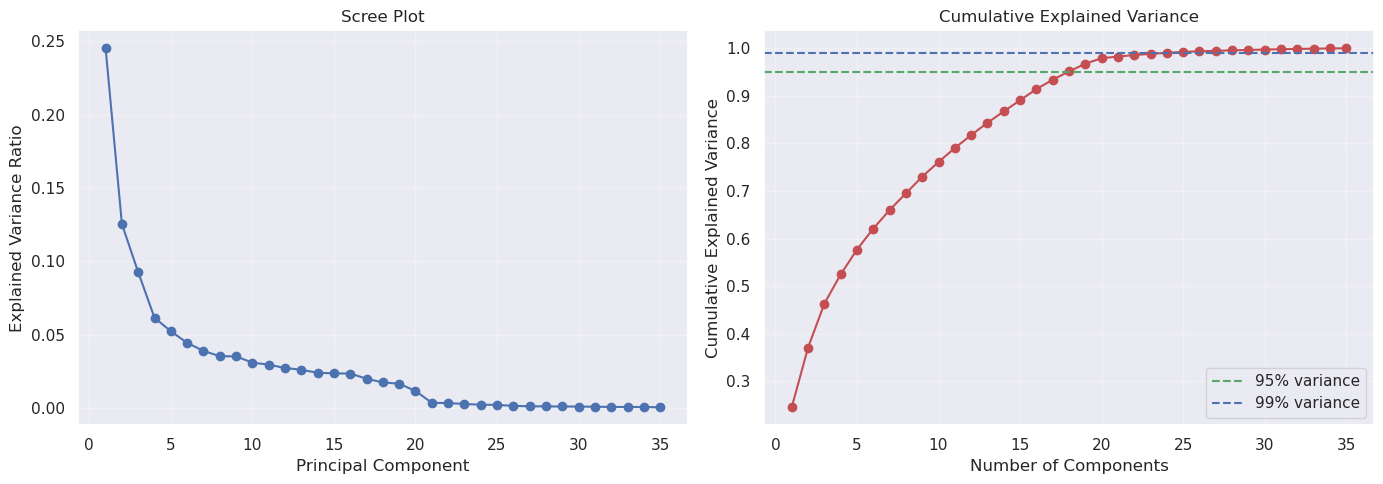


PCA Analysis:
  Components for 95% variance: 18/35
  Components for 99% variance: 24/35

PCA Transformation Applied:
  Original features: 35
  PCA components: 18
  Variance retained: 0.9512
  Train shape: (8619, 18)
  Val shape: (2873, 18)
  Test shape: (2873, 18)


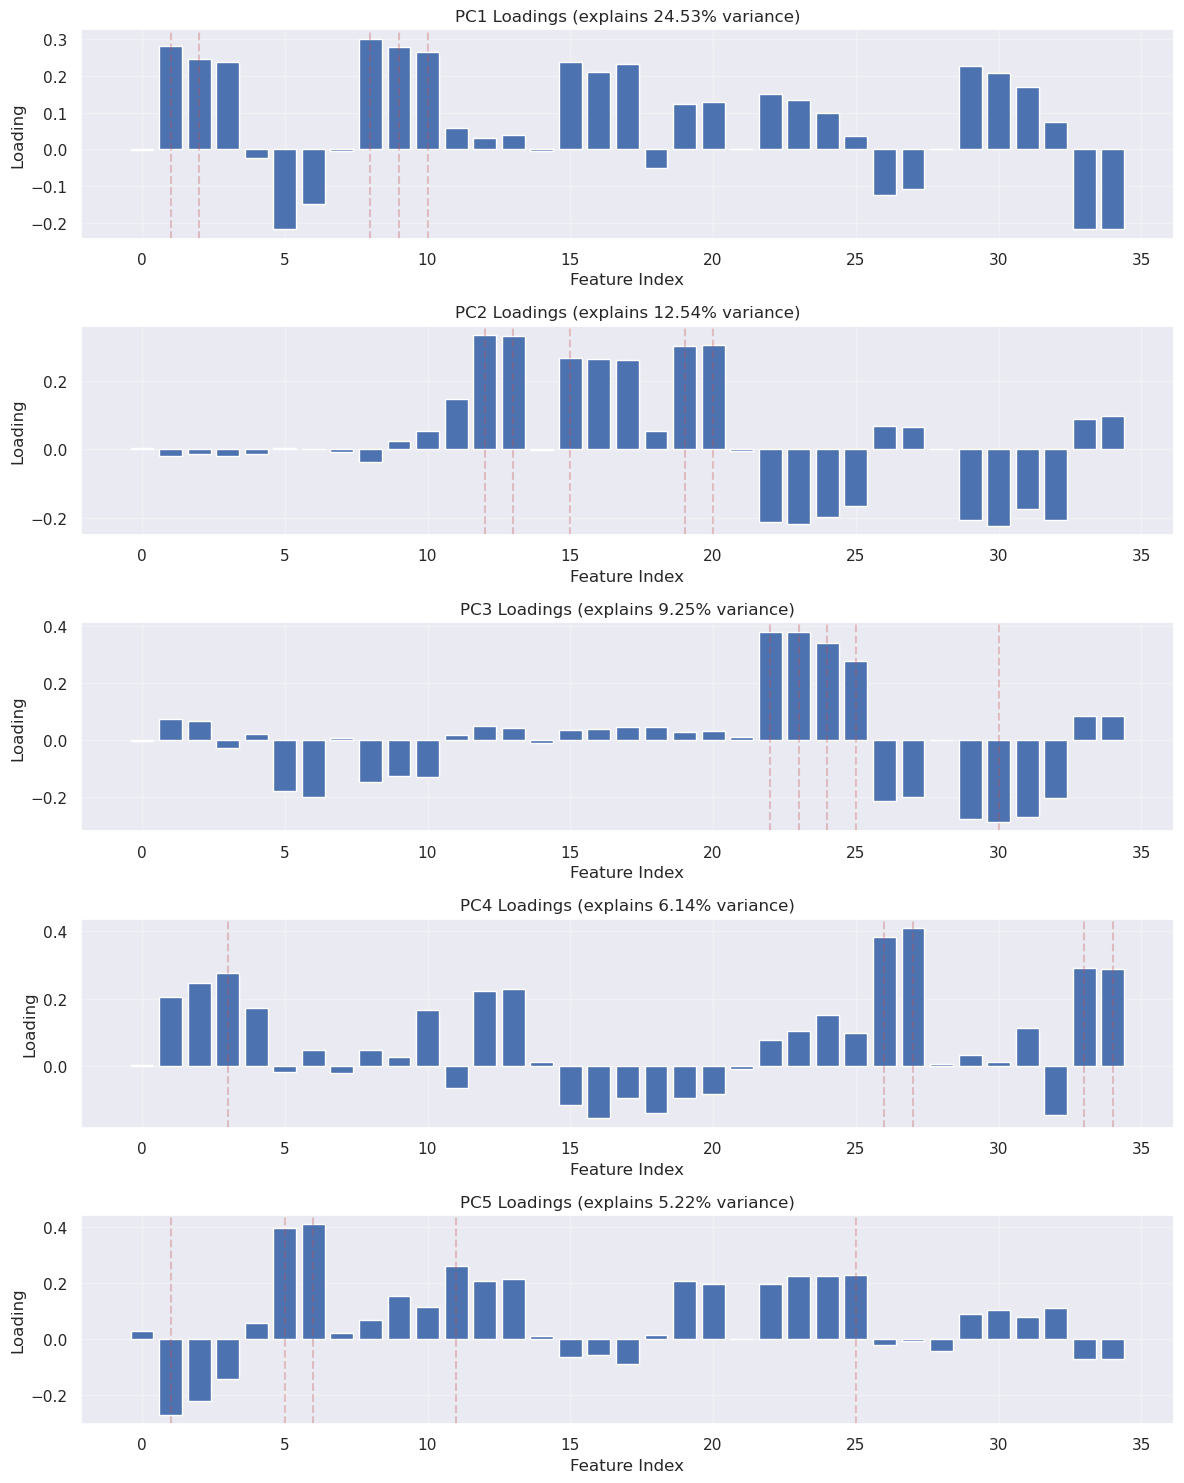


Top 5 features for first 3 PCs:

PC1:
  std_index: 0.3009
  std_thumb: 0.2825
  max_amp_index: 0.2786
  tkeo_index: 0.2643
  max_amp_thumb: 0.2453

PC2:
  irregularity_index: 0.3345
  wl_ratio_index: 0.3316
  wl_ratio_middle: 0.3065
  irregularity_middle: 0.3036
  std_middle: 0.2672

PC3:
  max_amp_ring: 0.3792
  std_ring: 0.3764
  tkeo_ring: 0.3409
  max_amp_pinky: -0.2868
  sparsity_ring: 0.2763


In [10]:
# ============================================================================
# PCA INTEGRATION
# ============================================================================

# 1. Scale features (fit on trainval, transform train/val/test)
scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Fit PCA on trainval and determine optimal number of components
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_trainval_scaled)

# Plot explained variance to choose n_components
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
             pca_full.explained_variance_ratio_, 'bo-')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'ro-')
axes[1].axhline(y=0.95, color='g', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='b', linestyle='--', label='99% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find n_components for 95% and 99% variance
n_comp_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_comp_99 = np.argmax(cumsum_variance >= 0.99) + 1
print(f"\nPCA Analysis:")
print(f"  Components for 95% variance: {n_comp_95}/{X_trainval.shape[1]}")
print(f"  Components for 99% variance: {n_comp_99}/{X_trainval.shape[1]}")

# 3. Choose n_components 
N_COMPONENTS = n_comp_95  

# 4. Apply PCA transformation
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_trainval_pca = pca.fit_transform(X_trainval_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\nPCA Transformation Applied:")
print(f"  Original features: {X_trainval.shape[1]}")
print(f"  PCA components: {N_COMPONENTS}")
print(f"  Variance retained: {cumsum_variance[N_COMPONENTS-1]:.4f}")
print(f"  Train shape: {X_train_pca.shape}")
print(f"  Val shape: {X_val_pca.shape}")
print(f"  Test shape: {X_test_pca.shape}")

# 5. Visualize PCA component loadings (top components)
n_top_components = min(5, N_COMPONENTS)
fig, axes = plt.subplots(n_top_components, 1, figsize=(12, 3*n_top_components))
if n_top_components == 1:
    axes = [axes]

for i in range(n_top_components):
    axes[i].bar(range(len(feature_names)), pca.components_[i])
    axes[i].set_xlabel('Feature Index')
    axes[i].set_ylabel('Loading')
    axes[i].set_title(f'PC{i+1} Loadings (explains {pca.explained_variance_ratio_[i]:.2%} variance)')
    axes[i].grid(True, alpha=0.3)
    
    # Highlight top contributing features
    top_idx = np.argsort(np.abs(pca.components_[i]))[-5:]
    for idx in top_idx:
        axes[i].axvline(x=idx, color='r', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Print top contributing features for first few components
print("\nTop 5 features for first 3 PCs:")
for i in range(min(3, N_COMPONENTS)):
    top_idx = np.argsort(np.abs(pca.components_[i]))[-5:][::-1]
    print(f"\nPC{i+1}:")
    for idx in top_idx:
        print(f"  {feature_names[idx]}: {pca.components_[i][idx]:.4f}")

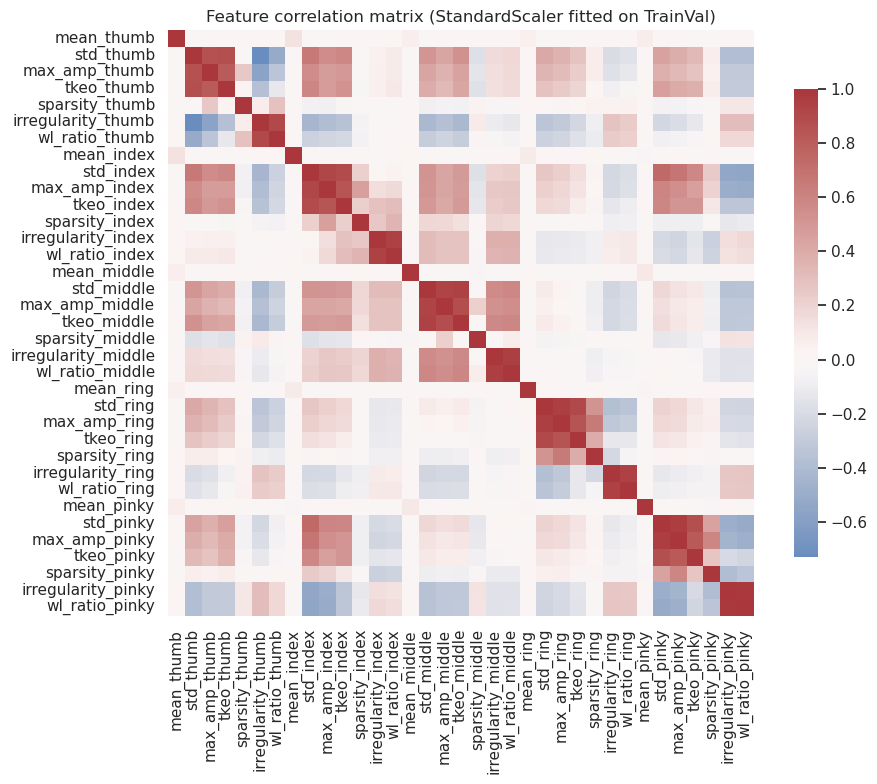

In [13]:
scaler_corr = StandardScaler()
X_trainval_scaled = scaler_corr.fit_transform(X_trainval)
df_trainval_scaled = pd.DataFrame(X_trainval_scaled, columns=feature_names)

corr = df_trainval_scaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix (StandardScaler fitted on TrainVal)")
plt.tight_layout()
plt.show()

In [14]:
#Without PCA

param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [3, 4],
    "subsample": [0.6, 0.8],
    "criterion": ['friedman_mse'],
}

def build_model(params: dict) -> Pipeline:
    gbr = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        criterion=params["criterion"],
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", MultiOutputRegressor(gbr, n_jobs=-1)),
    ])

grid = list(ParameterGrid(param_grid))
print(f"Grid size: {len(grid)} candidates")

all_idx = np.arange(X_trainval.shape[0])

best_params: dict | None = None
best_cv_r2 = -np.inf
best_cv_r2_std = np.inf
best_cv_rmse = np.inf
best_cv_rmse_std = np.inf
t0 = time.time()

for k, params in enumerate(grid, start=1):
    fold_train_r2: list[float] = []
    fold_val_r2: list[float] = []
    fold_val_rmse: list[float] = []

    for val_idx in folds:
        train_idx = np.setdiff1d(all_idx, val_idx)
        X_tr, Y_tr = X_trainval[train_idx], Y_trainval[train_idx]
        X_va, Y_va = X_trainval[val_idx], Y_trainval[val_idx]

        model = build_model(params)
        model.fit(X_tr, Y_tr)
        Y_tr_pred = model.predict(X_tr)
        Y_va_pred = model.predict(X_va)

        fold_train_r2.append(float(r2_score(Y_tr, Y_tr_pred, multioutput="variance_weighted")))
        fold_val_r2.append(float(r2_score(Y_va, Y_va_pred, multioutput="variance_weighted")))
        fold_val_rmse.append(float(np.sqrt(mean_squared_error(Y_va, Y_va_pred))))

    cv_r2_mean = float(np.mean(fold_val_r2))
    cv_r2_std = float(np.std(fold_val_r2))
    cv_rmse_mean = float(np.mean(fold_val_rmse))
    cv_rmse_std = float(np.std(fold_val_rmse))
    tr_r2_mean = float(np.mean(fold_train_r2))

    if cv_r2_mean > best_cv_r2:
        best_cv_r2 = cv_r2_mean
        best_cv_r2_std = cv_r2_std
        best_cv_rmse = cv_rmse_mean
        best_cv_rmse_std = cv_rmse_std
        best_params = params

    elapsed = time.time() - t0
    print(
        f"[{k:>2}/{len(grid)}] train R^2={tr_r2_mean:+.3f} | CV val R^2={cv_r2_mean:+.3f}±{cv_r2_std:.3f} "
        f"| CV val RMSE={cv_rmse_mean:.3f}±{cv_rmse_std:.3f} | params={params}",
        flush=True,
    )

print("\nBest params (selected by mean CV val R^2):", best_params)
print(f"Best CV val R^2 (mean±std): {best_cv_r2:+.3f}±{best_cv_r2_std:.3f}")
print(f"Best CV val RMSE (mean±std): {best_cv_rmse:.3f}±{best_cv_rmse_std:.3f}")

final_model = build_model(best_params)
final_model.fit(X_trainval, Y_trainval)

Y_trainval_pred = final_model.predict(X_trainval)
r2_trainval = float(r2_score(Y_trainval, Y_trainval_pred, multioutput="variance_weighted"))
print(f"\nTRAINVAL R^2 (variance-weighted, final model): {r2_trainval:+.3f}")

Y_test_pred = final_model.predict(X_test)
r2_overall = float(r2_score(Y_test, Y_test_pred, multioutput="variance_weighted"))
rmse_overall = float(np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
mae_overall = float(mean_absolute_error(Y_test, Y_test_pred))
print(f"TEST R^2 (variance-weighted): {r2_overall:+.3f}")
print(f"TEST RMSE (overall): {rmse_overall:.3f}")
print(f"TEST MAE  (overall): {mae_overall:.3f}")

Grid size: 24 candidates
[ 1/24] train R^2=+0.601 | CV val R^2=+0.584±0.006 | CV val RMSE=27.765±0.113 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}
[ 2/24] train R^2=+0.599 | CV val R^2=+0.582±0.005 | CV val RMSE=27.856±0.118 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
[ 3/24] train R^2=+0.664 | CV val R^2=+0.644±0.007 | CV val RMSE=25.696±0.180 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6}
[ 4/24] train R^2=+0.663 | CV val R^2=+0.641±0.006 | CV val RMSE=25.796±0.160 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
[ 5/24] train R^2=+0.678 | CV val R^2=+0.654±0.006 | CV val RMSE=25.327±0.133 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.6}


In [15]:
results_original = {
    'name': 'Original Features',
    'n_features': X_trainval.shape[1],  
    'best_params': best_params.copy(),
    'cv_r2_mean': best_cv_r2,
    'cv_r2_std': best_cv_r2_std,
    'cv_rmse_mean': best_cv_rmse,
    'cv_rmse_std': best_cv_rmse_std,
    'trainval_r2': r2_trainval,
    'test_r2': r2_overall,
    'test_rmse': rmse_overall,
    'test_mae': mae_overall,
    'Y_test_pred': Y_test_pred.copy(),  
}


PER-FINGER PERFORMANCE ANALYSIS

THUMB (joint 3):
  R² = +0.666
  RMSE = 13.215

INDEX (joint 6):
  R² = +0.724
  RMSE = 18.600

MIDDLE (joint 8):
  R² = +0.742
  RMSE = 26.318

RING (joint 11):
  R² = +0.833
  RMSE = 19.424

PINKY (joint 14):
  R² = +0.877
  RMSE = 17.502


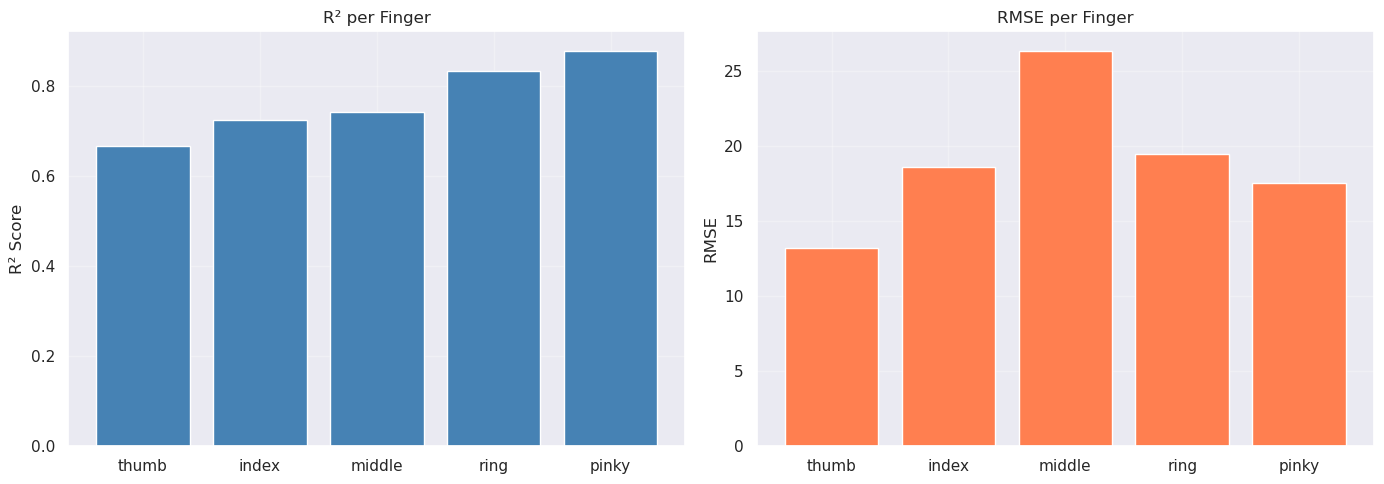


OBSERVATIONS:
Fingers with lower R²/higher RMSE may be due to:
- Less independent muscle activation (coupled movements)
- Smaller range of motion → lower signal-to-noise ratio
- Anatomical constraints (ring/pinky often move together)


In [16]:
# Per-finger analysis
print("\n" + "="*60)
print("PER-FINGER PERFORMANCE ANALYSIS")
print("="*60)

for i, (joint_name, finger_name) in enumerate(zip(joint_names, FINGER_NAMES)):
    r2_finger = r2_score(Y_test[:, i], Y_test_pred[:, i])
    rmse_finger = np.sqrt(mean_squared_error(Y_test[:, i], Y_test_pred[:, i]))
    
    print(f"\n{finger_name.upper()} (joint {GLOVE_JOINTS_1BASED[i]}):")
    print(f"  R² = {r2_finger:+.3f}")
    print(f"  RMSE = {rmse_finger:.3f}")

# Visualize per-finger performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r2_per_finger = [r2_score(Y_test[:, i], Y_test_pred[:, i]) 
                 for i in range(len(FINGER_NAMES))]
rmse_per_finger = [np.sqrt(mean_squared_error(Y_test[:, i], Y_test_pred[:, i])) 
                   for i in range(len(FINGER_NAMES))]

axes[0].bar(FINGER_NAMES, r2_per_finger, color='steelblue')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² per Finger')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].bar(FINGER_NAMES, rmse_per_finger, color='coral')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE per Finger')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Explain differences
print("\nOBSERVATIONS:")
print("Fingers with lower R²/higher RMSE may be due to:")
print("- Less independent muscle activation (coupled movements)")
print("- Smaller range of motion → lower signal-to-noise ratio")
print("- Anatomical constraints (ring/pinky often move together)")

In [17]:
#PCA model

param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [3, 4],
    "subsample": [0.6, 0.8],
    "criterion": ['friedman_mse'],
}

def build_model(params: dict) -> Pipeline:
    gbr = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        criterion=params["criterion"],
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", MultiOutputRegressor(gbr, n_jobs=-1)),
    ])

grid = list(ParameterGrid(param_grid))
print(f"Grid size: {len(grid)} candidates")

all_idx = np.arange(X_trainval_pca.shape[0])

best_params: dict | None = None
best_cv_r2 = -np.inf
best_cv_r2_std = np.inf
best_cv_rmse = np.inf
best_cv_rmse_std = np.inf
t0 = time.time()

for k, params in enumerate(grid, start=1):
    fold_train_r2: list[float] = []
    fold_val_r2: list[float] = []
    fold_val_rmse: list[float] = []

    for val_idx in folds:
        train_idx = np.setdiff1d(all_idx, val_idx)
        X_tr, Y_tr = X_trainval_pca[train_idx], Y_trainval[train_idx]
        X_va, Y_va = X_trainval_pca[val_idx], Y_trainval[val_idx]

        model = build_model(params)
        model.fit(X_tr, Y_tr)
        Y_tr_pred = model.predict(X_tr)
        Y_va_pred = model.predict(X_va)

        fold_train_r2.append(float(r2_score(Y_tr, Y_tr_pred, multioutput="variance_weighted")))
        fold_val_r2.append(float(r2_score(Y_va, Y_va_pred, multioutput="variance_weighted")))
        fold_val_rmse.append(float(np.sqrt(mean_squared_error(Y_va, Y_va_pred))))

    cv_r2_mean = float(np.mean(fold_val_r2))
    cv_r2_std = float(np.std(fold_val_r2))
    cv_rmse_mean = float(np.mean(fold_val_rmse))
    cv_rmse_std = float(np.std(fold_val_rmse))
    tr_r2_mean = float(np.mean(fold_train_r2))
    
    if cv_r2_mean > best_cv_r2:
        best_cv_r2 = cv_r2_mean
        best_cv_r2_std = cv_r2_std
        best_cv_rmse = cv_rmse_mean
        best_cv_rmse_std = cv_rmse_std
        best_params = params

    elapsed = time.time() - t0
    print(
        f"[{k:>2}/{len(grid)}] train R^2={tr_r2_mean:+.3f} | CV val R^2={cv_r2_mean:+.3f}±{cv_r2_std:.3f} "
        f"| CV val RMSE={cv_rmse_mean:.3f}±{cv_rmse_std:.3f} | params={params}",
        flush=True,
    )

print("\nBest params (selected by mean CV val R^2):", best_params)
print(f"Best CV val R^2 (mean±std): {best_cv_r2:+.3f}±{best_cv_r2_std:.3f}")
print(f"Best CV val RMSE (mean±std): {best_cv_rmse:.3f}±{best_cv_rmse_std:.3f}")

final_model = build_model(best_params)
final_model.fit(X_trainval_pca, Y_trainval)

Y_trainval_pred = final_model.predict(X_trainval_pca)
r2_trainval = float(r2_score(Y_trainval, Y_trainval_pred, multioutput="variance_weighted"))
print(f"\nTRAINVAL R^2 (variance-weighted, final model): {r2_trainval:+.3f}")

Y_test_pred = final_model.predict(X_test_pca)
r2_overall = float(r2_score(Y_test, Y_test_pred, multioutput="variance_weighted"))
rmse_overall = float(np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
mae_overall = float(mean_absolute_error(Y_test, Y_test_pred))
print(f"TEST R^2 (variance-weighted): {r2_overall:+.3f}")
print(f"TEST RMSE (overall): {rmse_overall:.3f}")
print(f"TEST MAE  (overall): {mae_overall:.3f}")

Grid size: 24 candidates
[ 1/24] train R^2=+0.555 | CV val R^2=+0.540±0.006 | CV val RMSE=29.215±0.157 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}
[ 2/24] train R^2=+0.554 | CV val R^2=+0.538±0.006 | CV val RMSE=29.291±0.157 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
[ 3/24] train R^2=+0.594 | CV val R^2=+0.575±0.008 | CV val RMSE=28.095±0.208 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.6}
[ 4/24] train R^2=+0.593 | CV val R^2=+0.572±0.008 | CV val RMSE=28.174±0.202 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
[ 5/24] train R^2=+0.607 | CV val R^2=+0.581±0.007 | CV val RMSE=27.897±0.185 | params={'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.6}


In [18]:
results_pca = {
    'name': f'PCA ({N_COMPONENTS} components)',
    'n_features': N_COMPONENTS,  
    'best_params': best_params.copy(),
    'cv_r2_mean': best_cv_r2,
    'cv_r2_std': best_cv_r2_std,
    'cv_rmse_mean': best_cv_rmse,
    'cv_rmse_std': best_cv_rmse_std,
    'trainval_r2': r2_trainval,
    'test_r2': r2_overall,
    'test_rmse': rmse_overall,
    'test_mae': mae_overall,
    'Y_test_pred': Y_test_pred.copy(),
}

In [19]:
results = [results_original, results_pca]

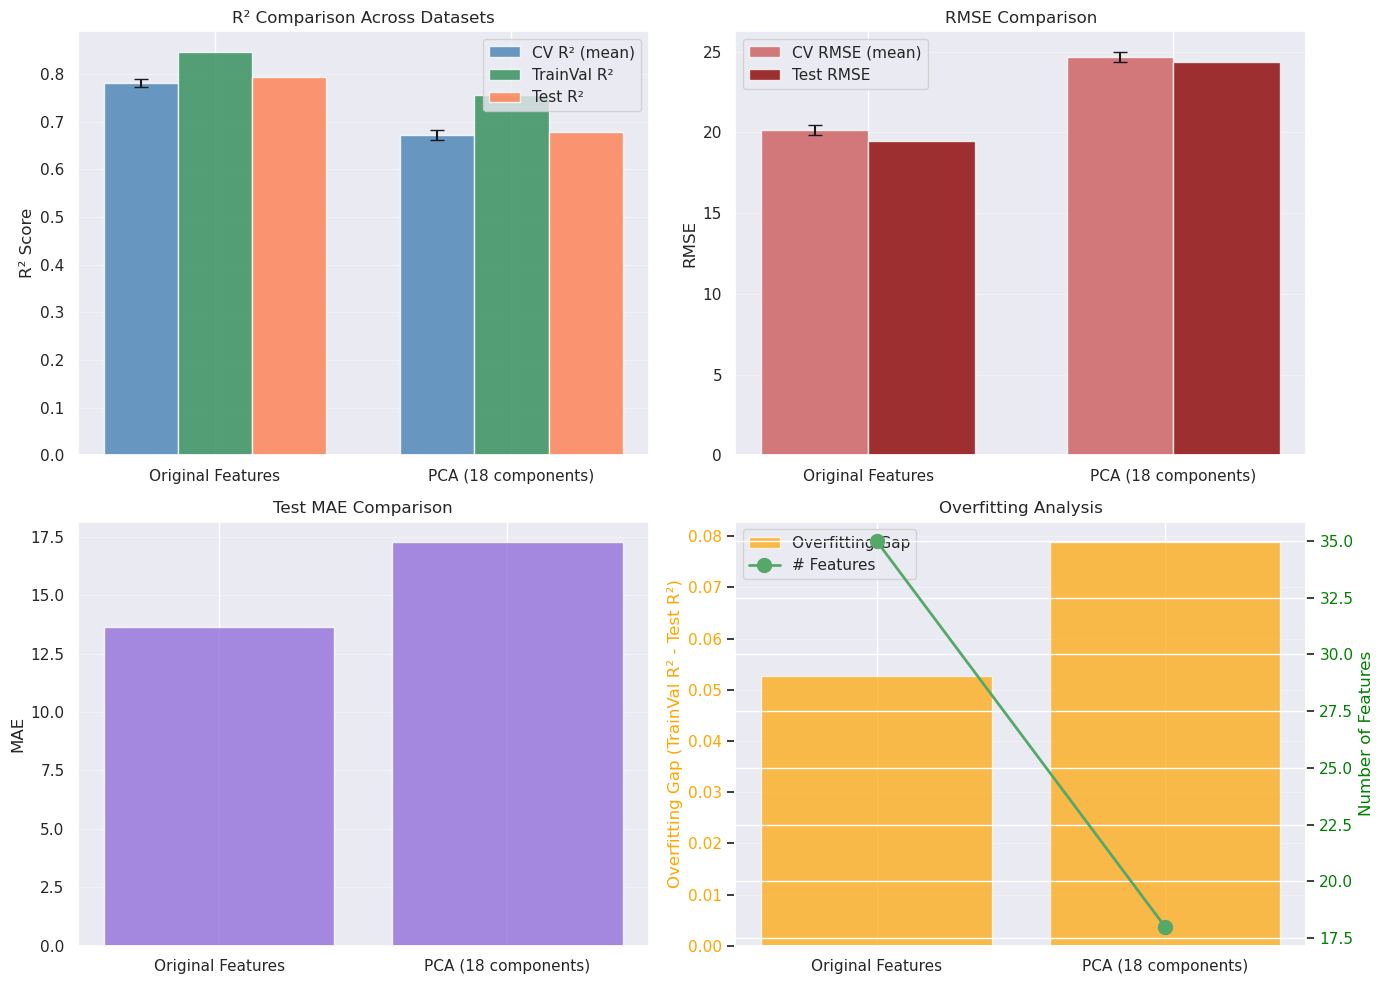

In [20]:
# ============================================================================
# VISUALIZATION : Performance Metrics Comparison
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: R² Scores
ax = axes[0, 0]
x_pos = np.arange(len(results))
width = 0.25

cv_r2 = [r['cv_r2_mean'] for r in results]
cv_r2_err = [r['cv_r2_std'] for r in results]
trainval_r2 = [r['trainval_r2'] for r in results]
test_r2 = [r['test_r2'] for r in results]

ax.bar(x_pos - width, cv_r2, width, label='CV R² (mean)', yerr=cv_r2_err, 
       capsize=5, alpha=0.8, color='steelblue')
ax.bar(x_pos, trainval_r2, width, label='TrainVal R²', alpha=0.8, color='seagreen')
ax.bar(x_pos + width, test_r2, width, label='Test R²', alpha=0.8, color='coral')

ax.set_ylabel('R² Score')
ax.set_title('R² Comparison Across Datasets')
ax.set_xticks(x_pos)
ax.set_xticklabels([r['name'] for r in results])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Plot 2: RMSE Comparison
ax = axes[0, 1]
cv_rmse = [r['cv_rmse_mean'] for r in results]
cv_rmse_err = [r['cv_rmse_std'] for r in results]
test_rmse = [r['test_rmse'] for r in results]

x_pos = np.arange(len(results))
width = 0.35

ax.bar(x_pos - width/2, cv_rmse, width, label='CV RMSE (mean)', 
       yerr=cv_rmse_err, capsize=5, alpha=0.8, color='indianred')
ax.bar(x_pos + width/2, test_rmse, width, label='Test RMSE', 
       alpha=0.8, color='darkred')

ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels([r['name'] for r in results])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: MAE Comparison
ax = axes[1, 0]
test_mae = [r['test_mae'] for r in results]

ax.bar(range(len(results)), test_mae, alpha=0.8, color='mediumpurple')
ax.set_ylabel('MAE')
ax.set_title('Test MAE Comparison')
ax.set_xticks(range(len(results)))
ax.set_xticklabels([r['name'] for r in results])
ax.grid(axis='y', alpha=0.3)

# Plot 4: Feature Count & Overfitting Analysis
ax = axes[1, 1]
x_pos = np.arange(len(results))

# Overfitting gap: TrainVal R² - Test R²
overfit_gap = [r['trainval_r2'] - r['test_r2'] for r in results]
n_features = [r['n_features'] for r in results]

ax2 = ax.twinx()

bars = ax.bar(x_pos, overfit_gap, alpha=0.7, color='orange', label='Overfitting Gap')
line = ax2.plot(x_pos, n_features, 'go-', linewidth=2, markersize=10, 
                label='# Features')

ax.set_ylabel('Overfitting Gap (TrainVal R² - Test R²)', color='orange')
ax2.set_ylabel('Number of Features', color='green')
ax.set_title('Overfitting Analysis')
ax.set_xticks(x_pos)
ax.set_xticklabels([r['name'] for r in results])
ax.tick_params(axis='y', labelcolor='orange')
ax2.tick_params(axis='y', labelcolor='green')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


GENERATING PREDICTION VISUALIZATIONS


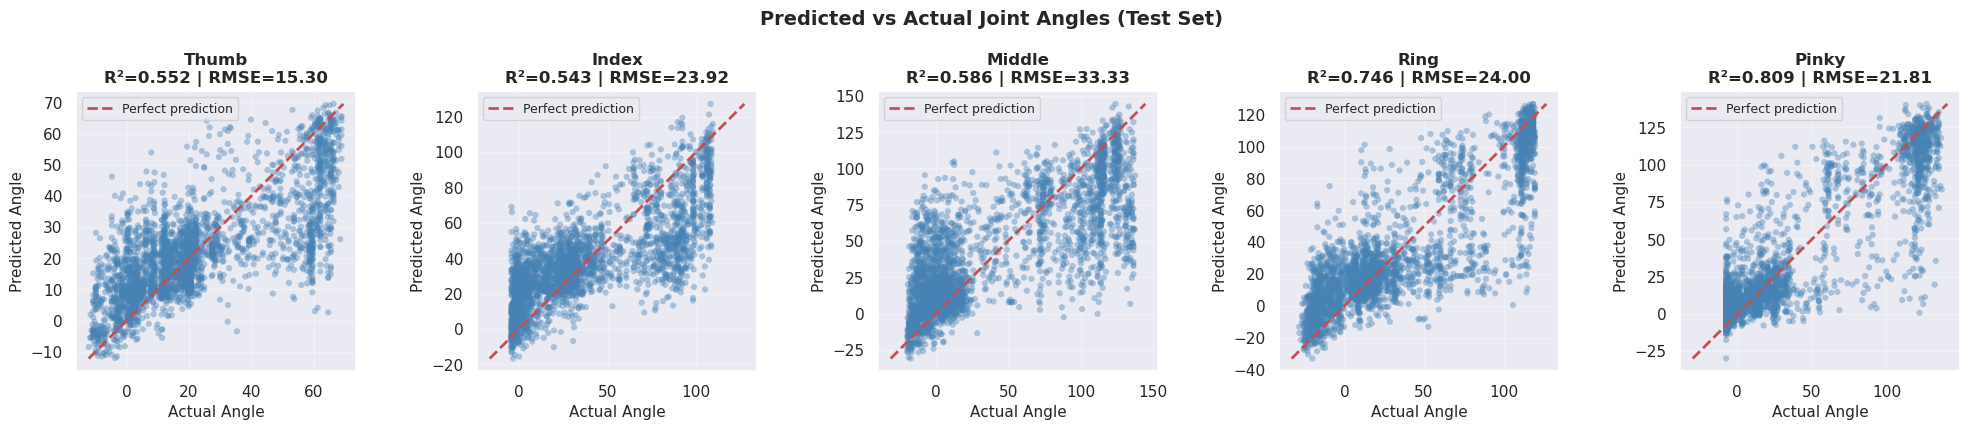

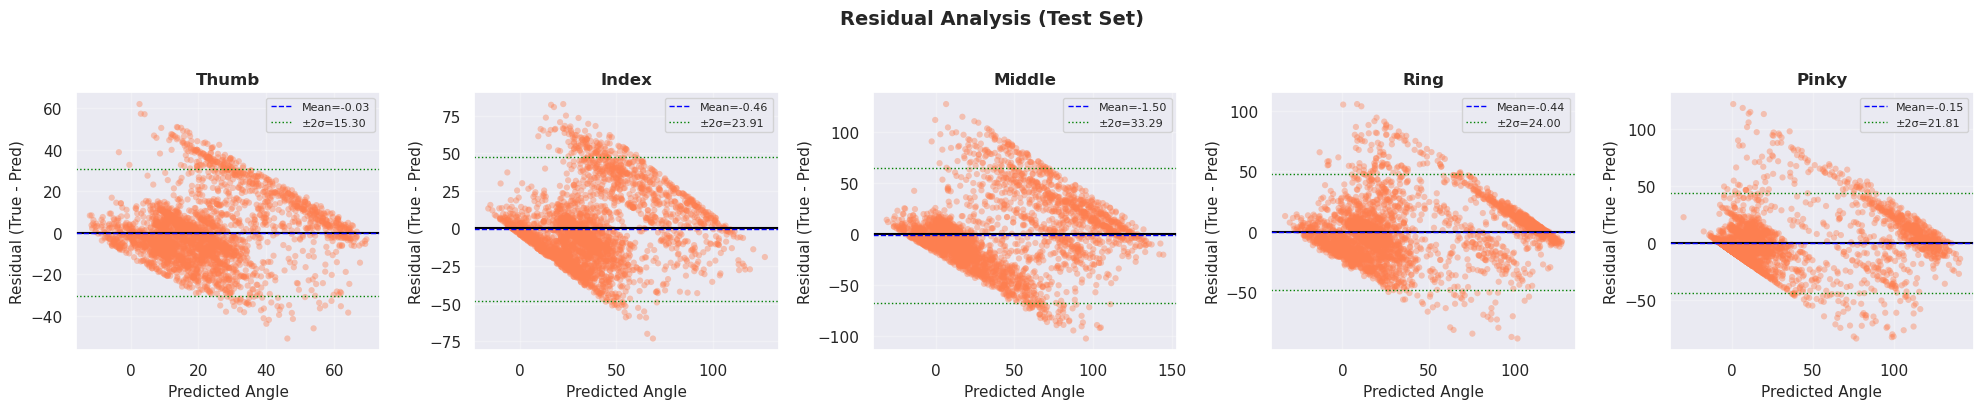

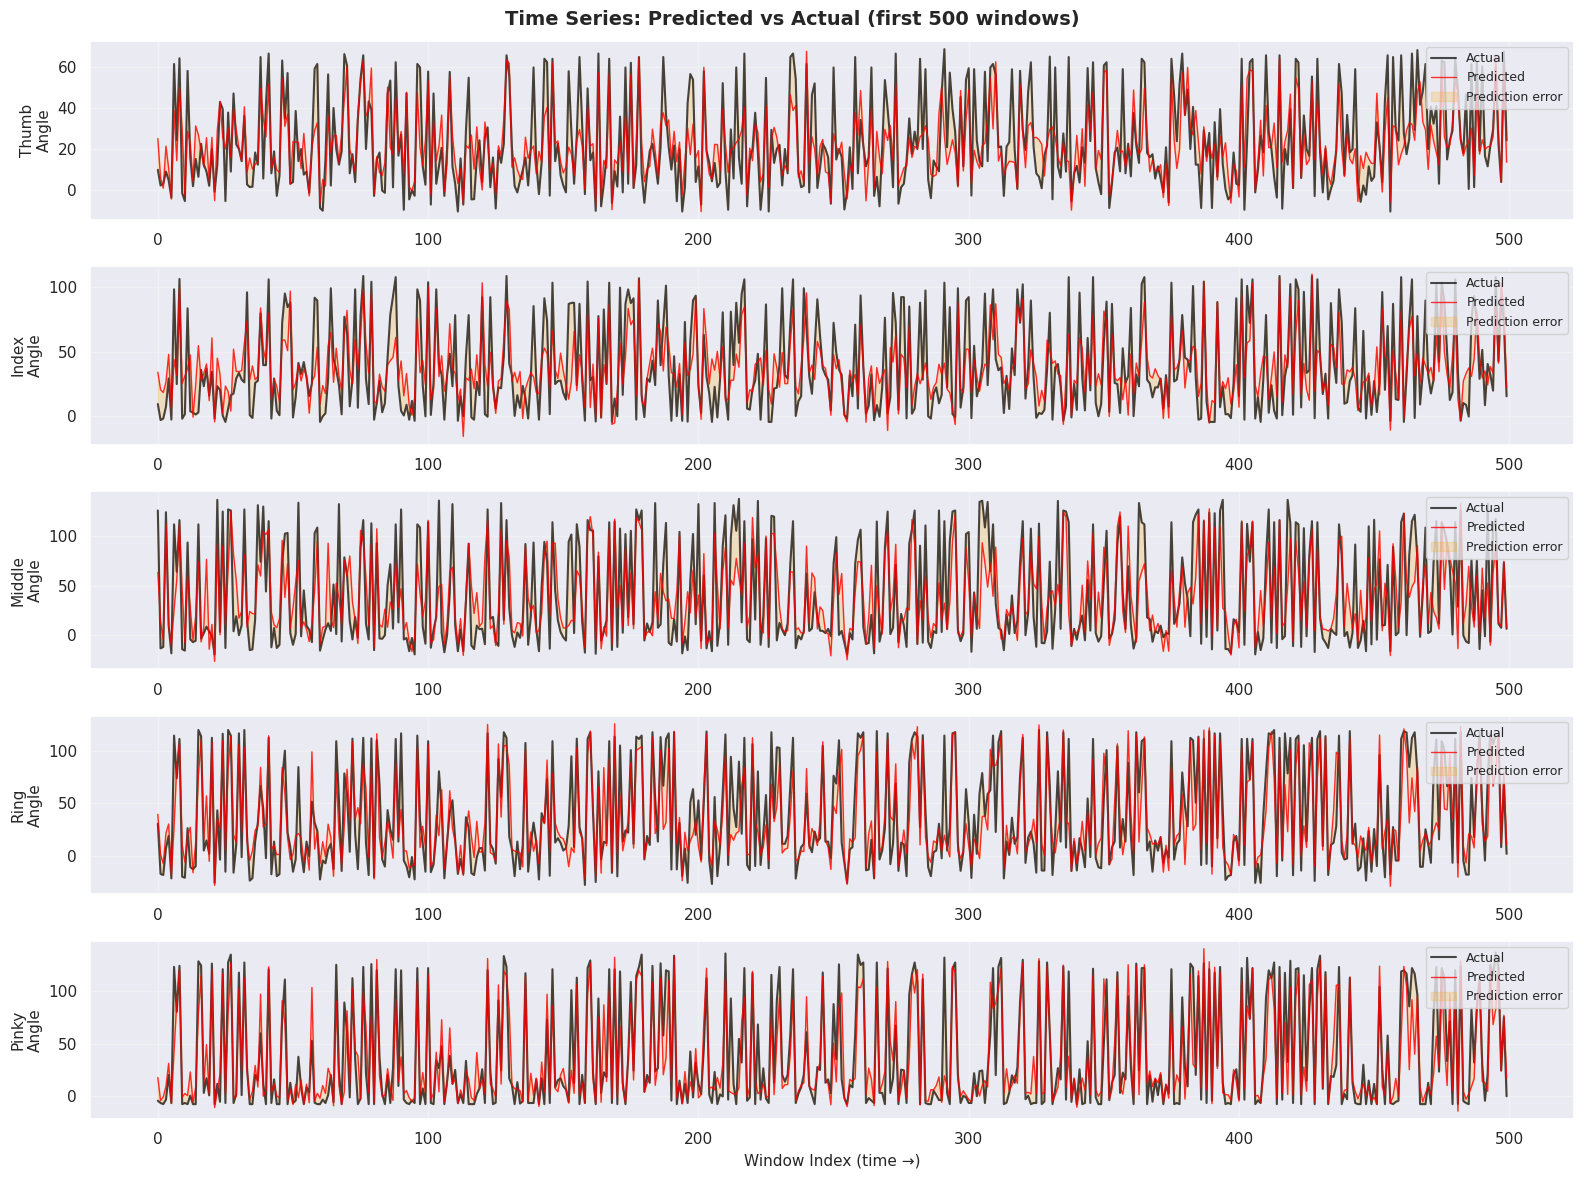

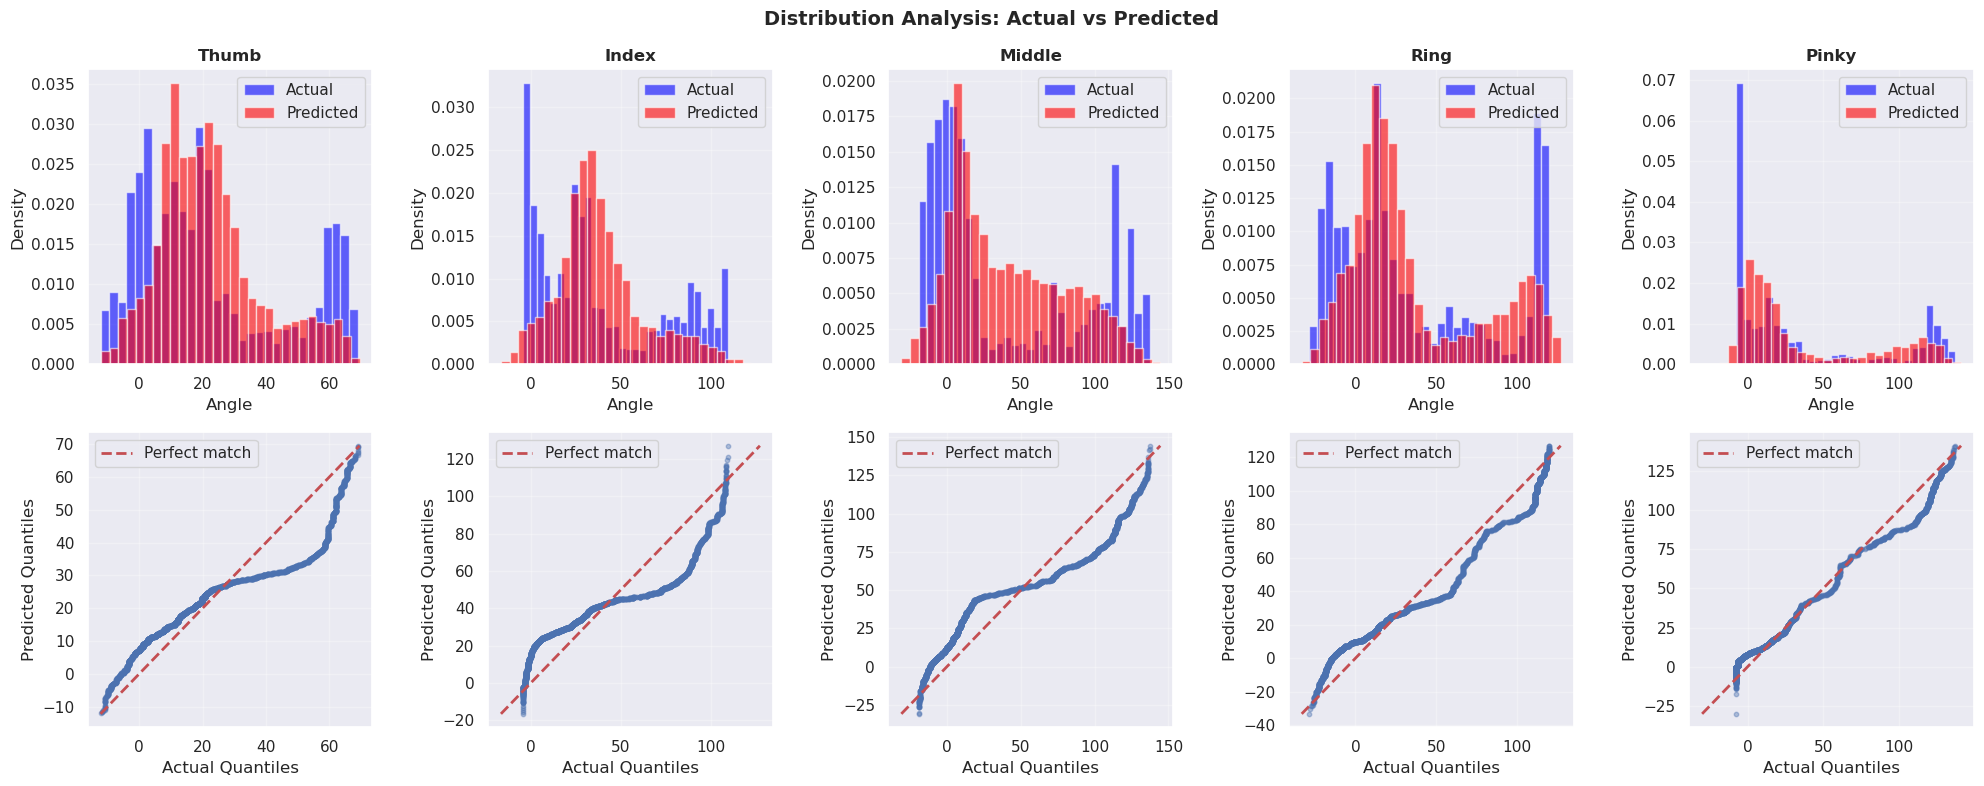

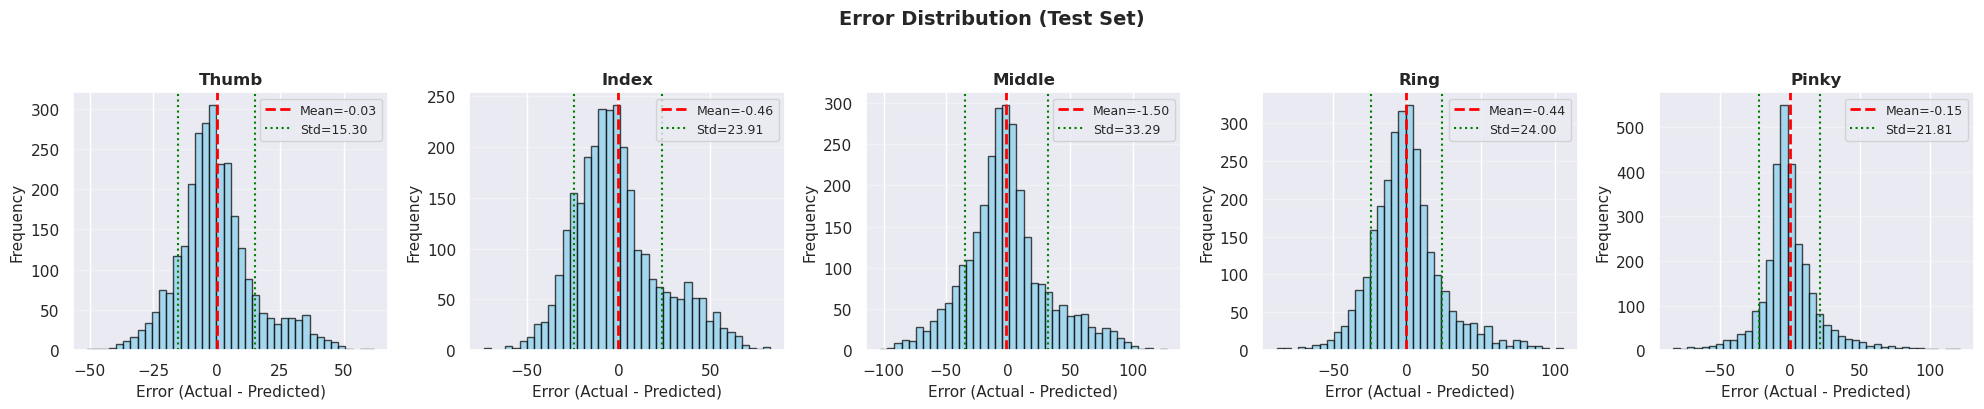

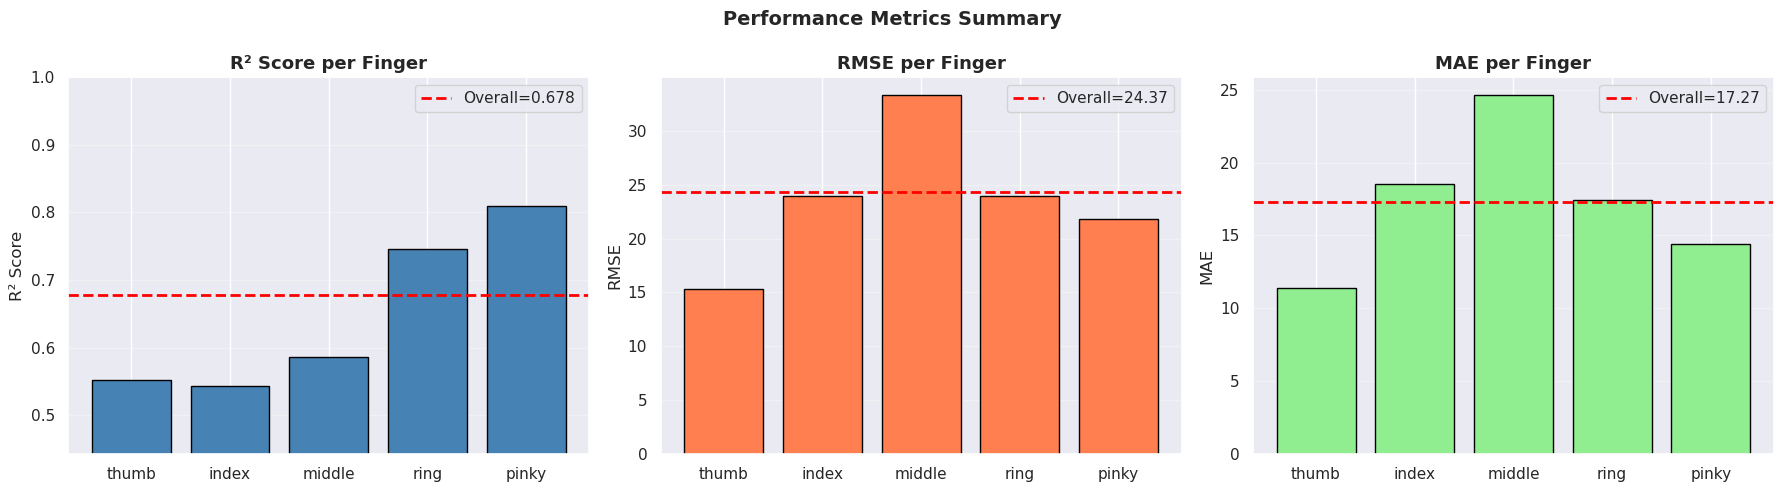

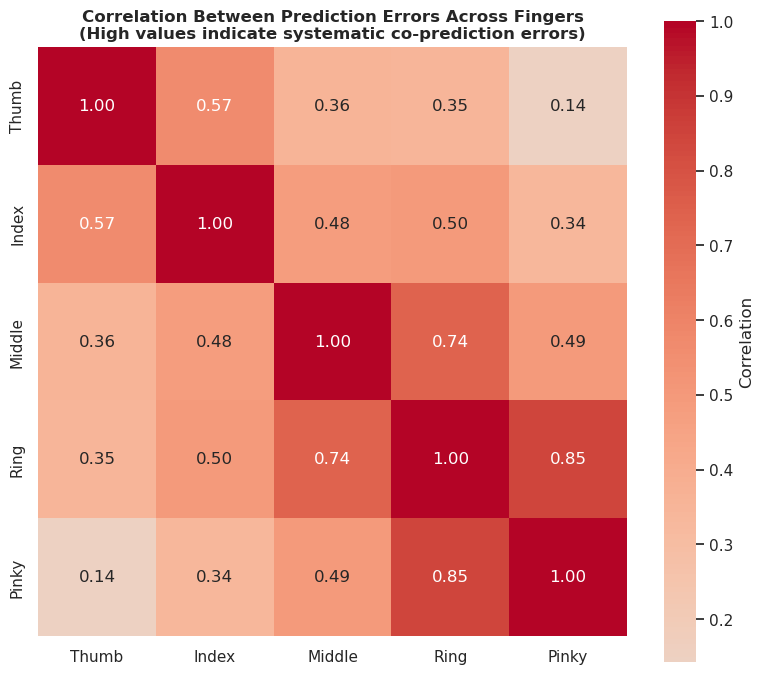

/tmp/ipykernel_1074/3718594209.py:308: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_err_right.boxplot(boxplot_data, labels=[f.capitalize() for f in FINGER_NAMES],


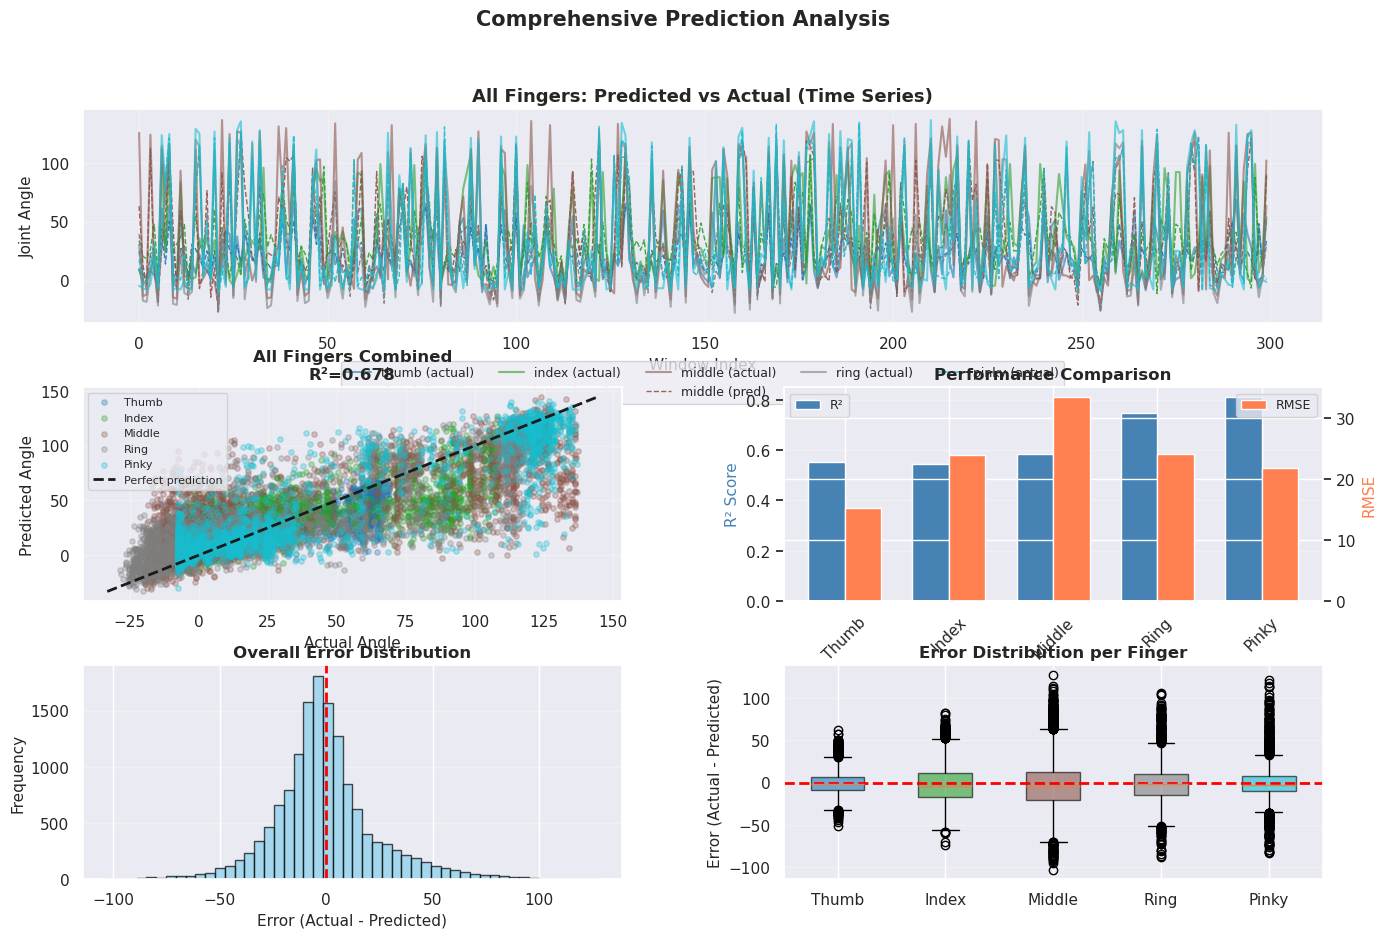


DETAILED PER-FINGER STATISTICS

THUMB:
  R² Score:        +0.5522
  RMSE:            15.3006
  MAE:             11.3716
  Mean Error:      -0.0346
  Std Error:       15.3006
  Max Error:       62.0299
  Actual range:    [-12.16, 68.91]
  Predicted range: [-11.99, 69.52]

INDEX:
  R² Score:        +0.5429
  RMSE:            23.9180
  MAE:             18.5443
  Mean Error:      -0.4641
  Std Error:       23.9135
  Max Error:       82.6574
  Actual range:    [-4.31, 109.37]
  Predicted range: [-16.64, 127.13]

MIDDLE:
  R² Score:        +0.5861
  RMSE:            33.3270
  MAE:             24.6287
  Mean Error:      -1.4969
  Std Error:       33.2934
  Max Error:       127.3979
  Actual range:    [-19.31, 137.33]
  Predicted range: [-30.95, 144.45]

RING:
  R² Score:        +0.7457
  RMSE:            24.0013
  MAE:             17.4265
  Mean Error:      -0.4386
  Std Error:       23.9973
  Max Error:       105.8781
  Actual range:    [-28.56, 119.65]
  Predicted range: [-33.15, 126.84]



In [21]:
# ============================================================================
# VISUALIZATION: PREDICTED VS TRUE VALUES
# ============================================================================

print("\n" + "="*70)
print("GENERATING PREDICTION VISUALIZATIONS")
print("="*70)

# 1. SCATTER PLOTS: Predicted vs Actual (one per finger)
# ============================================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

r2_per_finger = []
for i, (ax, finger) in enumerate(zip(axes, FINGER_NAMES)):
    y_true = Y_test[:, i]
    y_pred = Y_test_pred[:, i]
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_per_finger.append(r2)
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.4, s=20, c='steelblue', edgecolors='none')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            'r--', lw=2, label='Perfect prediction', zorder=5)
    
    # Formatting
    ax.set_xlabel('Actual Angle', fontsize=11)
    ax.set_ylabel('Predicted Angle', fontsize=11)
    ax.set_title(f'{finger.capitalize()}\nR²={r2:.3f} | RMSE={rmse:.2f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Joint Angles (Test Set)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 2. RESIDUAL PLOTS (to check for bias/patterns)
# ============================================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, finger) in enumerate(zip(axes, FINGER_NAMES)):
    y_true = Y_test[:, i]
    y_pred = Y_test_pred[:, i]
    residuals = y_true - y_pred
    
    # Residual scatter
    ax.scatter(y_pred, residuals, alpha=0.4, s=20, c='coral', edgecolors='none')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    
    # Mean and std of residuals
    mean_res = np.mean(residuals)
    std_res = np.std(residuals)
    ax.axhline(y=mean_res, color='blue', linestyle='--', linewidth=1, 
               label=f'Mean={mean_res:.2f}')
    ax.axhline(y=mean_res + 2*std_res, color='green', linestyle=':', linewidth=1)
    ax.axhline(y=mean_res - 2*std_res, color='green', linestyle=':', linewidth=1,
               label=f'±2σ={std_res:.2f}')
    
    ax.set_xlabel('Predicted Angle', fontsize=11)
    ax.set_ylabel('Residual (True - Pred)', fontsize=11)
    ax.set_title(f'{finger.capitalize()}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Analysis (Test Set)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 3. TIME-SERIES VISUALIZATION (sample of predictions over time)
# ============================================================================
# Show first 500 windows (adjust as needed)
n_display = min(500, Y_test.shape[0])

fig, axes = plt.subplots(5, 1, figsize=(16, 12))

for i, (ax, finger) in enumerate(zip(axes, FINGER_NAMES)):
    time_axis = np.arange(n_display)
    
    ax.plot(time_axis, Y_test[:n_display, i], 
            label='Actual', color='black', linewidth=1.5, alpha=0.7)
    ax.plot(time_axis, Y_test_pred[:n_display, i], 
            label='Predicted', color='red', linewidth=1, alpha=0.8)
    
    # Fill between for error visualization
    ax.fill_between(time_axis, 
                     Y_test[:n_display, i], 
                     Y_test_pred[:n_display, i],
                     alpha=0.2, color='orange', label='Prediction error')
    
    ax.set_ylabel(f'{finger.capitalize()}\nAngle', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    if i == len(axes) - 1:
        ax.set_xlabel('Window Index (time →)', fontsize=11)

plt.suptitle(f'Time Series: Predicted vs Actual (first {n_display} windows)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. DISTRIBUTION COMPARISON (Actual vs Predicted)
# ============================================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, finger in enumerate(FINGER_NAMES):
    # Histogram
    axes[0, i].hist(Y_test[:, i], bins=30, alpha=0.6, color='blue', 
                    label='Actual', density=True)
    axes[0, i].hist(Y_test_pred[:, i], bins=30, alpha=0.6, color='red', 
                    label='Predicted', density=True)
    axes[0, i].set_title(f'{finger.capitalize()}', fontweight='bold')
    axes[0, i].set_xlabel('Angle')
    axes[0, i].set_ylabel('Density')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Q-Q plot (quantile-quantile)
    sorted_true = np.sort(Y_test[:, i])
    sorted_pred = np.sort(Y_test_pred[:, i])
    axes[1, i].scatter(sorted_true, sorted_pred, alpha=0.4, s=10)
    
    min_val = min(sorted_true.min(), sorted_pred.min())
    max_val = max(sorted_true.max(), sorted_pred.max())
    axes[1, i].plot([min_val, max_val], [min_val, max_val], 
                    'r--', lw=2, label='Perfect match')
    axes[1, i].set_xlabel('Actual Quantiles')
    axes[1, i].set_ylabel('Predicted Quantiles')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Distribution Analysis: Actual vs Predicted', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 5. ERROR DISTRIBUTION (Histogram of residuals)
# ============================================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, finger) in enumerate(zip(axes, FINGER_NAMES)):
    residuals = Y_test[:, i] - Y_test_pred[:, i]
    
    ax.hist(residuals, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Add statistics
    mean_err = np.mean(residuals)
    std_err = np.std(residuals)
    ax.axvline(mean_err, color='red', linestyle='--', linewidth=2, 
               label=f'Mean={mean_err:.2f}')
    ax.axvline(mean_err + std_err, color='green', linestyle=':', linewidth=1.5)
    ax.axvline(mean_err - std_err, color='green', linestyle=':', linewidth=1.5,
               label=f'Std={std_err:.2f}')
    
    ax.set_xlabel('Error (Actual - Predicted)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{finger.capitalize()}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Error Distribution (Test Set)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# 6. PERFORMANCE SUMMARY BAR CHARTS
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² scores
r2_scores = [r2_score(Y_test[:, i], Y_test_pred[:, i]) for i in range(5)]
axes[0].bar(FINGER_NAMES, r2_scores, color='steelblue', edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0].axhline(y=r2_overall, color='red', linestyle='--', linewidth=2,
                label=f'Overall={r2_overall:.3f}')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score per Finger', fontsize=13, fontweight='bold')
axes[0].set_ylim([min(r2_scores) - 0.1, 1.0])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
rmse_scores = [np.sqrt(mean_squared_error(Y_test[:, i], Y_test_pred[:, i])) 
               for i in range(5)]
axes[1].bar(FINGER_NAMES, rmse_scores, color='coral', edgecolor='black')
axes[1].axhline(y=rmse_overall, color='red', linestyle='--', linewidth=2,
                label=f'Overall={rmse_overall:.2f}')
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('RMSE per Finger', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# MAE
mae_scores = [mean_absolute_error(Y_test[:, i], Y_test_pred[:, i]) 
              for i in range(5)]
axes[2].bar(FINGER_NAMES, mae_scores, color='lightgreen', edgecolor='black')
axes[2].axhline(y=mae_overall, color='red', linestyle='--', linewidth=2,
                label=f'Overall={mae_overall:.2f}')
axes[2].set_ylabel('MAE', fontsize=12)
axes[2].set_title('MAE per Finger', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Performance Metrics Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 7. HEATMAP: Correlation between prediction errors across fingers
# ============================================================================
residuals_matrix = Y_test - Y_test_pred
error_corr = np.corrcoef(residuals_matrix.T)

plt.figure(figsize=(8, 7))
sns.heatmap(error_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, 
            xticklabels=[f.capitalize() for f in FINGER_NAMES],
            yticklabels=[f.capitalize() for f in FINGER_NAMES],
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Prediction Errors Across Fingers\n(High values indicate systematic co-prediction errors)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# 8. COMBINED VISUALIZATION: All fingers in one plot
# ============================================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Top: Combined time series
ax_ts = fig.add_subplot(gs[0, :])
n_display = min(300, Y_test.shape[0])
colors = plt.cm.tab10(np.linspace(0, 1, 5))

for i, (finger, color) in enumerate(zip(FINGER_NAMES, colors)):
    ax_ts.plot(Y_test[:n_display, i], label=f'{finger} (actual)', 
               color=color, linewidth=1.5, alpha=0.6, linestyle='-')
    ax_ts.plot(Y_test_pred[:n_display, i], label=f'{finger} (pred)', 
               color=color, linewidth=1, alpha=0.9, linestyle='--')

ax_ts.set_xlabel('Window Index', fontsize=11)
ax_ts.set_ylabel('Joint Angle', fontsize=11)
ax_ts.set_title('All Fingers: Predicted vs Actual (Time Series)', 
                fontsize=13, fontweight='bold')
ax_ts.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=9)
ax_ts.grid(True, alpha=0.3)

# Middle left: Overall scatter
ax_scatter = fig.add_subplot(gs[1, 0])
for i, (finger, color) in enumerate(zip(FINGER_NAMES, colors)):
    ax_scatter.scatter(Y_test[:, i], Y_test_pred[:, i], 
                      alpha=0.3, s=15, c=[color], label=finger.capitalize())

min_all = min(Y_test.min(), Y_test_pred.min())
max_all = max(Y_test.max(), Y_test_pred.max())
ax_scatter.plot([min_all, max_all], [min_all, max_all], 
                'k--', lw=2, label='Perfect prediction')
ax_scatter.set_xlabel('Actual Angle', fontsize=11)
ax_scatter.set_ylabel('Predicted Angle', fontsize=11)
ax_scatter.set_title(f'All Fingers Combined\nR²={r2_overall:.3f}', 
                    fontsize=12, fontweight='bold')
ax_scatter.legend(fontsize=8)
ax_scatter.grid(True, alpha=0.3)

# Middle right: Performance comparison
ax_perf = fig.add_subplot(gs[1, 1])
x = np.arange(len(FINGER_NAMES))
width = 0.35
ax_perf.bar(x - width/2, r2_scores, width, label='R²', color='steelblue')
ax_perf_twin = ax_perf.twinx()
ax_perf_twin.bar(x + width/2, rmse_scores, width, label='RMSE', color='coral')
ax_perf.set_ylabel('R² Score', fontsize=11, color='steelblue')
ax_perf_twin.set_ylabel('RMSE', fontsize=11, color='coral')
ax_perf.set_xticks(x)
ax_perf.set_xticklabels([f.capitalize() for f in FINGER_NAMES], rotation=45)
ax_perf.set_title('Performance Comparison', fontsize=12, fontweight='bold')
ax_perf.legend(loc='upper left', fontsize=9)
ax_perf_twin.legend(loc='upper right', fontsize=9)
ax_perf.grid(True, alpha=0.3, axis='y')

# Bottom: Error analysis
ax_err_left = fig.add_subplot(gs[2, 0])
all_residuals = (Y_test - Y_test_pred).flatten()
ax_err_left.hist(all_residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax_err_left.axvline(0, color='red', linestyle='--', linewidth=2)
ax_err_left.set_xlabel('Error (Actual - Predicted)', fontsize=11)
ax_err_left.set_ylabel('Frequency', fontsize=11)
ax_err_left.set_title('Overall Error Distribution', fontsize=12, fontweight='bold')
ax_err_left.grid(True, alpha=0.3, axis='y')

ax_err_right = fig.add_subplot(gs[2, 1])
boxplot_data = [Y_test[:, i] - Y_test_pred[:, i] for i in range(5)]
bp = ax_err_right.boxplot(boxplot_data, labels=[f.capitalize() for f in FINGER_NAMES],
                           patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax_err_right.axhline(0, color='red', linestyle='--', linewidth=2)
ax_err_right.set_ylabel('Error (Actual - Predicted)', fontsize=11)
ax_err_right.set_title('Error Distribution per Finger', fontsize=12, fontweight='bold')
ax_err_right.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comprehensive Prediction Analysis', fontsize=15, fontweight='bold')
plt.show()


# 9. PRINT DETAILED STATISTICS
# ============================================================================
print("\n" + "="*70)
print("DETAILED PER-FINGER STATISTICS")
print("="*70)

for i, finger in enumerate(FINGER_NAMES):
    y_true = Y_test[:, i]
    y_pred = Y_test_pred[:, i]
    residuals = y_true - y_pred
    
    print(f"\n{finger.upper()}:")
    print(f"  R² Score:        {r2_scores[i]:+.4f}")
    print(f"  RMSE:            {rmse_scores[i]:.4f}")
    print(f"  MAE:             {mae_scores[i]:.4f}")
    print(f"  Mean Error:      {np.mean(residuals):+.4f}")
    print(f"  Std Error:       {np.std(residuals):.4f}")
    print(f"  Max Error:       {np.max(np.abs(residuals)):.4f}")
    print(f"  Actual range:    [{y_true.min():.2f}, {y_true.max():.2f}]")
    print(f"  Predicted range: [{y_pred.min():.2f}, {y_pred.max():.2f}]")

print("\n" + "="*70)